<a href="https://colab.research.google.com/github/DanielaDSMS/Evidence-of-AI-related-skills/blob/main/Trabajo_final_Mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 <h1 align="center">
  <font color="#8E44AD" face="Georgia", size = "10">Proyecto Final</font><br>
  <font color="#5A189A" face="Georgia" size="10">Minería de textos biomédicos</font>
</h1>




<font color="#240046" face="Georgia" size="4">
Profesora: Rosa Figueroa</font>
<br>
<font color="#240046" face="Georgia" size="4">
Alumno ayudante: José Pinto </font>
<br>
<font color="#240046" face="Georgia" size="4">
10 de julio 2026 </font>
<br>
<font color="#240046" face="Georgia" size="4">
Estudiante: Daniela Macaya</font>
</h1>



<font color="#240046" face="Georgia" size="6">
1. Introducción
</h1>




## 1.1 Contexto y motivación del problema

En la era digital contemporánea, la música se ha consolidado como uno de los canales de expresión humana más masivos del mundo. Con el crecimiento de las plataformas de streaming, la cantidad de información textual disponible en forma de letras de canciones ha alcanzado volúmenes sin precedentes, convirtiendo este dominio en un campo fértil para la Minería de Textos.

Sin embargo, el corpus lírico presenta desafíos particulares que lo diferencian de textos formales como noticias o artículos científicos: uso intensivo de metáforas, estructuras altamente repetitivas (estribillos), jerga cultural e informal, contracciones, onomatopeyas y palabras colapsadas sin separación. Estas características obligan a diseñar estrategias de preprocesamiento específicas para el dominio y ponen a prueba la capacidad de los modelos de clasificación de texto.

El presente proyecto se fundamenta en el análisis del Song Lyrics Dataset (Kaggle), un corpus que consolida la discografía textual de 21 artistas de renombre internacional y de géneros diversos (entre ellos Eminem, Taylor Swift, BTS, Coldplay y Ariana Grande). La motivación central del trabajo consiste en explorar si las herramientas automatizadas de minería de textos son capaces de desentrañar la identidad léxica y el perfil emocional que subyace a la obra de cada autor, transformando datos textuales informales en perfiles cuantitativos rigurosos, y determinar qué familia de modelos resulta más adecuada para este tipo de corpus.




## 1.2 Preguntas de investigación y objetivos

Objetivo general: desarrollar, evaluar y comparar críticamente el rendimiento de modelos estadísticos clásicos de Machine Learning frente a arquitecturas de Deep Learning en un problema de clasificación multiclase (predecir a cuál de los 21 artistas pertenece una canción a partir exclusivamente de su letra), complementando el enfoque predictivo con un análisis descriptivo del perfil emocional y léxico de los intérpretes.

Objetivos específicos:

Construir y depurar un corpus unificado de letras de canciones, aplicando pipelines de preprocesamiento diferenciados según la familia de modelo (limpieza profunda con lematización para modelos basados en TF-IDF; limpieza secuencial que preserva la estructura gramatical para redes neuronales).
Entrenar y optimizar modelos clásicos (Random Forest y SVM sobre representaciones TF-IDF) y arquitecturas de Deep Learning (LSTM, CNN 1D y BiLSTM con embeddings preentrenados GloVe), incorporando mecanismos de balanceo de clases y control de sobreajuste.

Evaluar comparativamente los modelos mediante métricas adecuadas al desbalance multiclase (Accuracy, Balanced Accuracy y F1-Score Macro), junto con un análisis de errores basado en matrices de confusión e importancia de características.

Caracterizar el perfil afectivo y léxico de los artistas mediante análisis de sentimiento (VADER), riqueza léxica y nubes de palabras.

Estructura del estudio en dos tareas. Este proyecto aborda dos tareas de clasificación complementarias sobre el mismo corpus y con protocolos experimentales idénticos. La primera, correspondiente al objetivo de la propuesta, es la clasificación de la polaridad emocional de las letras (sección 6); al no existir anotaciones humanas de sentimiento en el dataset, sus etiquetas se generan mediante VADER (supervisión débil), lo que se declara como limitación interpretativa. La segunda es la identificación del artista (secciones 4–5), un problema multiclase de 21 clases con etiquetas reales y verificables, incorporado precisamente para complementar la primera tarea con un banco de pruebas de mayor dificultad y con ground truth independiente. Ambas tareas alimentan la misma pregunta metodológica central de la propuesta: bajo qué condiciones las arquitecturas de Deep Learning justifican su complejidad frente a los modelos clásicos.

###Para guiar la experimentación se plantean las siguientes preguntas de investigación:

(los agregue para que quede más completo)

P1 — Perspectiva del modelamiento predictivo: ¿Cómo se compara el rendimiento de clasificadores clásicos como Random Forest y SVM alimentados con representaciones TF-IDF, frente a redes neuronales convolucionales (CNN 1D) y recurrentes (LSTM, BiLSTM con GloVe) basadas en Word Embeddings? ¿Logra la complejidad de los modelos profundos superar la capacidad de discriminación léxica de los métodos tradicionales en un corpus de tamaño acotado (~4000 canciones)?

P2 — Perspectiva del análisis léxico y emocional: ¿Es posible caracterizar y diferenciar la identidad artística de los autores mediante herramientas automatizadas de análisis de sentimiento (VADER) y de frecuencia léxica? ¿Permiten las métricas de valencia, la riqueza léxica y las nubes de palabras identificar un perfil lingüístico distintivo para cada cantante, y explicar los aciertos y confusiones de los clasificadores?

##1.3 Relevancia del problema
Resolver este problema posee relevancia práctica, metodológica y social. En la industria del streaming, comprender el perfil léxico y afectivo de las canciones permite optimizar los motores de recomendación, migrando desde clasificaciones rígidas por género musical hacia una personalización basada en los estados anímicos del usuario.

Desde el punto de vista metodológico, el proyecto aporta evidencia empírica sobre una discusión vigente en NLP: en qué condiciones los modelos de Deep Learning justifican su costo computacional frente a métodos clásicos. Trabajar con un corpus real, informal y de tamaño moderado permite evaluar los límites de las arquitecturas secuenciales cuando los datos son escasos y ruidosos, un escenario frecuente en aplicaciones reales.

Finalmente, en disciplinas vinculadas a la salud mental y el bienestar, este enfoque adquiere valor para la musicoterapia: clasificar automáticamente la carga emocional de las canciones facilita a psicólogos y terapeutas la construcción de catálogos clínicos precisos, permitiendo sintonizar de manera sistemática la música con el estado afectivo de un paciente y apoyar los procesos de regulación emocional mediante el arte lírico.

In [ ]:
import pandas as pd
import string
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from wordcloud import WordCloud
import nltk
import nltk.data
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import word_tokenize
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
!pip install wordsegment
!pip install contractions
import random
import tensorflow as tf
SEED = 42
random.seed(SEED)
np.random.seed(SEED)       # semilla de NumPy (usada por sklearn y Keras)
tf.random.set_seed(SEED)   # semilla de TensorFlow (pesos de las redes)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import pandas as pd
import os

drive.mount('/content/drive')
ruta = "/content/drive/MyDrive/MineriaDeTextos/csv"
#aca se puede poner la ruta en un drive o cargar individualmente cada .cvs
# o podria mejor unir todos los cvs en 1

df_all = []

# Esta seccion toma todas las canciones de los distintos artitas ya que eran muchos archivos csv para ponerlos
# individualmente
for filename in os.listdir(ruta):
    if filename.endswith('.csv'):
        filepath = os.path.join(ruta, filename)
        try:
            df = pd.read_csv(filepath)
            df_all.append(df)
            print(f"Loaded {filename} successfully.")
        except Exception as e:
            print(f"Error loading {filename}: {e}")

print(f"Total {len(df_all)} dataframes loaded.")


Mounted at /content/drive
Loaded DuaLipa.csv successfully.
Loaded ArianaGrande.csv successfully.
Loaded Rihanna.csv successfully.
Loaded Drake.csv successfully.
Loaded PostMalone.csv successfully.
Loaded Eminem.csv successfully.
Loaded JustinBieber.csv successfully.
Loaded Khalid.csv successfully.
Loaded CharliePuth.csv successfully.
Loaded KatyPerry.csv successfully.
Loaded BTS.csv successfully.
Loaded NickiMinaj.csv successfully.
Loaded LadyGaga.csv successfully.
Loaded SelenaGomez.csv successfully.
Loaded ColdPlay.csv successfully.
Loaded BillieEilish.csv successfully.
Loaded TaylorSwift.csv successfully.
Loaded Maroon5.csv successfully.
Loaded CardiB.csv successfully.
Loaded Beyonce.csv successfully.
Loaded EdSheeran.csv successfully.
Total 21 dataframes loaded.


In [ ]:
canciones = pd.concat(df_all, ignore_index=True)

# Antes me salio con un unnamed al juntar todos los .csv y esto es para que no los coloque
if 'Unnamed: 0' in canciones.columns:
    canciones = canciones.drop(columns=['Unnamed: 0'])

# Fijo las columnas desde 'artista' to 'lyric'
all_columns = canciones.columns.tolist()

try:
    start_idx = all_columns.index('Artist')
    end_idx = all_columns.index('Lyric')
    columns_to_keep = all_columns[start_idx : end_idx + 1]
    canciones = canciones[columns_to_keep]
except ValueError as e:
    print(f"Warning: no se encontro 'Artist' o 'Lyric'. Error: {e}")

# Simplificamos el nombre de BTS para evitar warnings de fuentes (caracteres coreanos)
canciones['Artist'] = canciones['Artist'].replace('BTS (방탄소년단)', 'BTS')

print(f"Total rows in 'canciones' DataFrame: {len(canciones)}")
display(canciones.head())

Total rows in 'canciones' DataFrame: 6027


,Artist,Title,Album,Year,Date,Lyric
0,Dua Lipa,New Rules,Dua Lipa,2017.0,2017-06-02,one one one one one talkin' in my sleep at n...
1,Dua Lipa,Don’t Start Now,Future Nostalgia,2019.0,2019-11-01,if you don't wanna see me did a full 80 craz...
2,Dua Lipa,IDGAF,Dua Lipa,2017.0,2017-06-02,you call me all friendly tellin' me how much y...
3,Dua Lipa,Blow Your Mind (Mwah),Dua Lipa,2016.0,2016-08-26,i know it's hot i know we've got something tha...
4,Dua Lipa,Be the One,Dua Lipa,2015.0,2015-10-30,i see the moon i see the moon i see the moon o...


In [ ]:
# Se creo una carpeta para guardar el archivo con todos los artistas y canciones (porque si se pone en el mismo lugar donde estan las canciones se carga y repite info al ejecutar denuevo)
nueva_carpeta = os.path.join(ruta, 'dataset_final')

# Creamos la carpeta si no existe
if not os.path.exists(nueva_carpeta):
    os.makedirs(nueva_carpeta)
    print(f"Carpeta creada: {nueva_carpeta}")

# Definimos la ruta final incluyendo la nueva carpeta
output_filepath = os.path.join(nueva_carpeta, 'canciones_combinadas.csv')

# Guardamos el archivo
canciones.to_csv(output_filepath, index=False)
print(f"'canciones' DataFrame successfully saved to: {output_filepath}")

'canciones' DataFrame successfully saved to: /content/drive/MyDrive/MineriaDeTextos/csv/dataset_final/canciones_combinadas.csv


<font color="#240046" face="Georgia" size="6">
2. Descripción de la base de datos
</h1>



## 2.1 Origen y fuente de los datos
El conjunto de datos utilizado corresponde al Song Lyrics Dataset, extraído de la plataforma Kaggle (deepshah16/song-lyrics-dataset). Este corpus contiene la discografía textual de 21 artistas musicales de renombre internacional pertenecientes a géneros diversos (pop, hip-hop/rap, R&B, rock alternativo y K-pop), entre ellos Eminem, Taylor Swift, Drake, Beyoncé, BTS, Coldplay y Billie Eilish.

La fuente distribuye los datos en 21 archivos .csv independientes (uno por artista). Como primer paso, se cargan y consolidan todos los archivos en un único DataFrame (canciones) para facilitar el análisis conjunto, y se estandariza el nombre del grupo BTS (originalmente registrado con caracteres coreanos) para evitar conflictos de codificación en las visualizaciones.

## 2.2 Tamaño del dataset y variables disponibles
Tras la unificación de las fuentes individuales, el dataset consolidado inicial queda constituido por 6.027 filas (cada fila representa una canción) y 6 columnas:

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `Artist` | Categórica (texto) | Nombre del intérprete. Constituye la **variable objetivo** del problema de clasificación multiclase (21 clases). |
| `Title` | Texto | Título de la canción. Se utiliza en la limpieza para detectar versiones alternativas (remixes, versiones en vivo). |
| `Album` | Categórica (texto) | Álbum al que pertenece la canción. |
| `Year` | Numérica (año) | Año de lanzamiento de la canción. |
| `Date` | Fecha | Fecha exacta de lanzamiento. |
| `Lyric` | Texto libre | Letra completa de la canción. Constituye la **variable predictora principal**, sobre la cual se aplica todo el procesamiento de NLP. |

Dado que el objetivo es clasificar al artista exclusivamente a partir del texto, el análisis se concentra en las variables Artist (target) y Lyric (predictor), mientras que Title, Album, Year y Date cumplen un rol de apoyo en la limpieza estructural y la contextualización temporal del corpus.


<font color="#240046" face="Georgia" size="5">
2.3 Análisis Exploratorio de Datos (EDA)
</h1>



## 2.3.1 Valores faltantes y duplicados
Se inicia el EDA evaluando la integridad del corpus: conteo de valores nulos por columna y detección de filas completamente duplicadas. Este diagnóstico es fundamental para dimensionar el trabajo de limpieza requerido antes del modelamiento.


In [ ]:
# Valores nulos y duplicados
print("Valores Nulos por Columna") #esto es para ver si hay lyrics donde este vacio o hayan letras duplicadas (por ejemplo, remezclas o versiones en vivo de la misma canción).
print(canciones.isnull().sum())

# Contar duplicados exactos
duplicados = canciones.duplicated().sum()
print(f"\n Filas Duplicadas ")
print(f"Se encontraron {duplicados} filas completamente duplicadas en el dataset.")

# Asegurarnos de que no haya nulos en nuestra variable principal ('Lyric')
# Busca y muestra solo las filas con 'Lyric' vacío
canciones_vacias = canciones[canciones['Lyric'].isna()]
#use .isna y no dropna para hacer el analisis primero aun no el preprocesamiento

Valores Nulos por Columna
Artist       0
Title        0
Album     1574
Year      1749
Date      1749
Lyric       46
dtype: int64

 Filas Duplicadas 
Se encontraron 0 filas completamente duplicadas en el dataset.


###2.3.2 Distribución de clases (canciones por artista)
Dado que se enfrenta un problema de clasificación multiclase, resulta vital verificar si el dataset está balanceado. Si un artista aporta muchas más canciones que los demás, los modelos podrían desarrollar un sesgo hacia esa clase mayoritaria, inflando artificialmente las métricas globales.


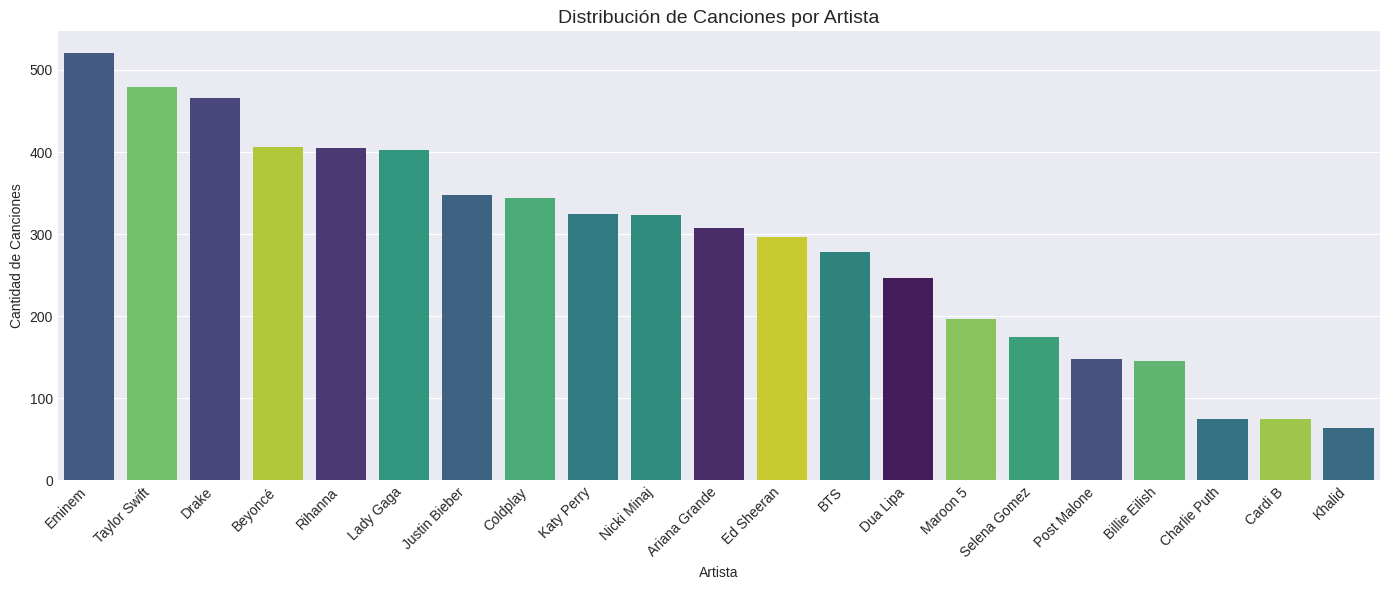

Artist
Eminem           521
Taylor Swift     479
Drake            466
Beyoncé          406
Rihanna          405
Lady Gaga        402
Justin Bieber    348
Coldplay         344
Katy Perry       325
Nicki Minaj      323
Ariana Grande    308
Ed Sheeran       296
BTS              278
Dua Lipa         247
Maroon 5         197
Selena Gomez     175
Post Malone      148
Billie Eilish    145
Charlie Puth      75
Cardi B           75
Khalid            64
Name: count, dtype: int64


In [ ]:
#Analizaremos cuántas canciones aporta cada uno de los 21 artistas al dataset.
#Es fundamental verificar si el dataset está balanceado o si algunos artistas tienen una sobrerrepresentación que pueda sesgar los modelos de clasificación.
# Gráfico de distribución de canciones por artista
plt.figure(figsize=(14, 6))
sns.countplot(data=canciones, x='Artist',
              order=canciones['Artist'].value_counts().index,
              hue='Artist', palette='viridis', legend=False)
plt.title('Distribución de Canciones por Artista', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cantidad de Canciones')
plt.xlabel('Artista')
plt.tight_layout()
plt.show()

# Mostrar los valores numéricos
print(canciones['Artist'].value_counts())

##2.3.3 Estadísticas descriptivas del texto (longitud de las letras)
Para cuantificar la complejidad de la variable predictora Lyric, se genera una característica derivada (Word_Count) que cuenta la cantidad de palabras por canción. Esta variable permite describir estadísticamente el corpus e identificar outliers: canciones instrumentales o con letra casi vacía en un extremo, y errores de scraping con longitudes desproporcionadas en el otro.


Estadísticas del Conteo de Palabras
count    6027.000000
mean      374.342459
std       302.295262
min         1.000000
25%       206.000000
50%       330.000000
75%       482.000000
max      5768.000000
Name: Word_Count, dtype: float64


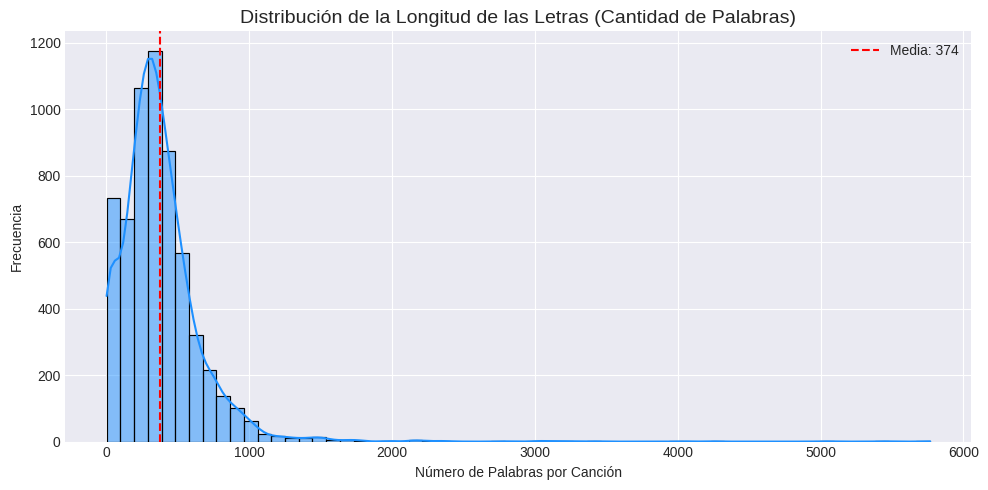

In [ ]:
#columna con el conteo de palabras y caracteres por canción
#Esto nos permitirá observar la distribución típica de las letras e identificar outliers (por ejemplo, canciones instrumentales con muy pocas palabras o pistas excesivamente largas)
canciones['Word_Count'] = canciones['Lyric'].apply(lambda x: len(str(x).split()))

# Mostrar estadísticas descriptivas numéricas
print("Estadísticas del Conteo de Palabras")
print(canciones['Word_Count'].describe())

# Gráfico de distribución de la longitud de las letras
plt.figure(figsize=(10, 5))
sns.histplot(canciones['Word_Count'], bins=60, kde=True, color='dodgerblue')
plt.title('Distribución de la Longitud de las Letras (Cantidad de Palabras)', fontsize=14)
plt.xlabel('Número de Palabras por Canción')
plt.ylabel('Frecuencia')
plt.axvline(canciones['Word_Count'].mean(), color='red', linestyle='dashed', linewidth=1.5, label=f"Media: {canciones['Word_Count'].mean():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

##2.3.4 Distribución temporal
Finalmente, se observa cómo se distribuyen las canciones según su año de lanzamiento, con el fin de comprender el rango temporal que abarca el corpus.


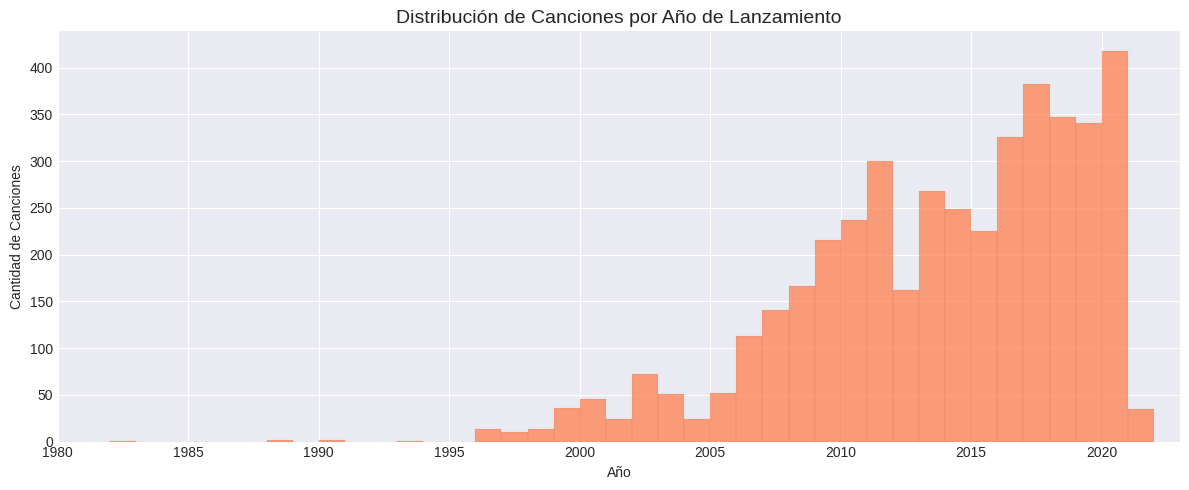

In [ ]:
# Visualizaremos cómo se distribuyen las canciones a lo largo de los años (Year) para entender el rango temporal que abarca el corpus de datos.
# Gráfico de distribución temporal
# Limpiar la columna Year por si tiene valores anómalos o nulos
canciones_year = canciones.dropna(subset=['Year'])

plt.figure(figsize=(12, 5))
sns.histplot(canciones_year['Year'], bins=int(canciones_year['Year'].max() - canciones_year['Year'].min()), kde=False, color='coral')
plt.title('Distribución de Canciones por Año de Lanzamiento', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Cantidad de Canciones')
plt.xlim(1980, canciones_year['Year'].max() + 1)
plt.tight_layout()
plt.show()

##2.3.5 Análisis de anomalías léxicas
Como paso exploratorio adicional, específico del dominio lírico, se inspeccionan las palabras más largas presentes en la columna Lyric original. Este análisis permite detectar patrones de ruido característicos del scraping de letras musicales que un EDA numérico tradicional no revelaría.

In [ ]:
# Extraer palabras únicas de la columna original 'Lyric' del DataFrame 'canciones'
todas_las_palabras_orig = set(' '.join(canciones['Lyric'].dropna().astype(str)).split())

# Ordenar por longitud de mayor a menor
palabras_largas = sorted([(word, len(word)) for word in todas_las_palabras_orig], key=lambda x: x[1], reverse=True)

print("--- Las 20 palabras más largas en 'canciones' (Columna Lyric Original) ---")
for i, (word, length) in enumerate(palabras_largas[:20], 1):
    print(f"{i}. {word} ({length} caracteres)")

--- Las 20 palabras más largas en 'canciones' (Columna Lyric Original) ---
1. httpwwwrollingstonecommusicnewseminemqaexclusivethemakingofthemarshallmatherslp00ixzz8t7kbh5l (93 caracteres)
2. _________________________________________________________________ (65 caracteres)
3. httpswwwsunflowerlyricscom0008aslongasyoulovemesonglyricshtml (61 caracteres)
4. tooooooooooooooooooooooooooooooooooooooooooooooooooooooo (56 caracteres)
5. rockstarrockstarrockstarrockstarrockstarrockstar (48 caracteres)
6. chubbachubbachubbachubbachubbachubbachubby (42 caracteres)
7. checkachickycheckachickycheckacheckachicka (42 caracteres)
8. pickedonchristopherreevesjustfornoreason (40 caracteres)
9. owattahazunomerodīmadanokorukitaruhimo (38 caracteres)
10. sonnakimarinantekankeinaitteuketometai (38 caracteres)
11. chikachikachikachikachikachikachika'' (37 caracteres)
12. steviewonderyouwillneverseethiseither (37 caracteres)
13. idonotknowwhatthefuckyouthoughtitwas (36 caracteres)
14. poooaaoooaaoooaaoooaaaoo

##2.3.6 Conclusiones del Análisis Exploratorio de Datos
Durante la fase de exploración se evaluó la integridad, distribución y características del corpus para fundamentar las decisiones de preprocesamiento:

1. Valores faltantes y duplicados. Las variables temporales y de agrupación (Album, Year, Date) presentan una cantidad significativa de datos faltantes (entre 1.574 y 1.749 registros nulos), lo cual no resulta crítico dado que no participan del modelamiento. La variable central del estudio, Lyric, presenta únicamente 46 valores vacíos, que deben tratarse en la etapa de limpieza. No se detectaron filas completamente duplicadas; sin embargo, la inspección de la variable Title sugiere la existencia de múltiples versiones de una misma canción (remixes, versiones en vivo, acústicas), lo que exige un tratamiento estructural posterior para evitar redundancia y fuga de información.

2. Distribución de clases. El análisis de frecuencias evidencia un desbalance considerable entre clases: en el extremo superior, Eminem (521 canciones), Taylor Swift (479) y Drake (466); en el extremo inferior, Charlie Puth (75), Cardi B (75) y Khalid (64). La clase mayoritaria supera a la minoritaria en una razón cercana a 8:1. Esta sobrerrepresentación impone la necesidad de aplicar técnicas de balanceo (pesos de clase) durante el entrenamiento y de privilegiar métricas robustas al desbalance (Balanced Accuracy, F1-Macro) en la evaluación.

3. Estadísticas descriptivas del texto y outliers. La longitud de las letras presenta una media de 374 palabras por canción, con mediana de 330 y tercer cuartil en 482. La distribución exhibe una asimetría positiva severa: el mínimo es de 1 palabra (canciones instrumentales o errores de extracción) y el máximo alcanza las 5.768 palabras (textos anómalos de scraping). Este comportamiento justifica la implementación de un filtro de longitud (20 a 800 palabras) en la etapa de preprocesamiento.

4. Distribución temporal. El corpus abarca desde la década de 1980 hasta la actualidad, con una fuerte concentración de registros a partir de 2005 y un pico de volumen en el período 2015–2020, coherente con la carrera activa de la mayoría de los artistas incluidos.

5. Anomalías léxicas. La inspección de tokens reveló palabras con longitudes anómalas (entre 34 y 93 caracteres), entre ellas: enlaces web colapsados (httpwwwrollingstonecommusic...), repeticiones de sílabas estróficas (rockstarrockstarrockstar...), alargamientos vocálicos (toooo...) y frases completas sin separación por espacios (idonotknowwhatthefuckyouthoughtitwas). Este hallazgo es fundamental, pues justifica la necesidad de una limpieza léxica profunda —normalización de repeticiones, segmentación de palabras colapsadas y expansión de contracciones— antes de la tokenización y vectorización.

Nota sobre correlaciones: al tratarse de un corpus esencialmente textual con una única variable predictora no estructurada (Lyric), no corresponde un análisis de correlación clásico entre variables numéricas. La relación entre el texto y la variable objetivo se aborda posteriormente mediante el análisis de frecuencias léxicas, la importancia de características del modelo Random Forest y el perfil de sentimiento por artista (secciones 5 y 5.6).


<font color="#240046" face="Georgia" size="6">
3. Preprocesamiento
</h1>



Esta etapa transforma el corpus crudo en un conjunto de datos apto para el modelamiento. El flujo se organiza en cinco fases: (1) normalización léxica inicial, (2) limpieza estructural del dataset, (3) preprocesamiento de texto diferenciado por familia de modelo, (4) feature engineering y transformación de variables, y (5) división en conjuntos de entrenamiento, validación y prueba. Cada decisión se justifica en función de los hallazgos del EDA (sección 2.3.6) y de los requerimientos técnicos de los modelos a entrenar.

##3.3.1 Limpieza profunda → Lyric_Clean (modelos clásicos con TF-IDF)

Sobre el texto ya normalizado se aplica: expansión de contracciones del inglés ("I'm" → "I am") con la librería contractions, eliminación de etiquetas estructurales ([Chorus], [Verse]), eliminación de caracteres no alfabéticos, filtrado de stopwords y de muletillas propias del canto ("oh", "yeah", "la", "na"), y lematización con WordNetLemmatizer para reducir las palabras a su forma base.

Dos decisiones merecen destacarse: (a) se preservan las negaciones ("not", "no", "never") pese a ser stopwords estándar, pues invierten el sentido de las frases y aportan valor discriminativo; (b) se agregan muletillas del dominio musical al listado de stopwords, ya que son transversales a todos los artistas y no aportan capacidad de discriminación.

Justificación: los modelos basados en TF-IDF (Random Forest, SVM) representan cada documento como una bolsa de términos ponderados, ignorando el orden. Se benefician de un vocabulario compacto donde variantes morfológicas de un mismo concepto ("love", "loved", "loving" → "love") se agrupan en una sola dimensión, reduciendo la dispersión de la matriz y concentrando la señal estadística.


In [ ]:
import sys
import re

from wordsegment import load, segment
load() # Cargar el corpus de segmentación

# Hacemos una copia explícita para no modificar el dataset original directamente .... miedito owo
df_clean = canciones.copy()

def limpieza_profunda_palabras(texto):
    if not isinstance(texto, str): return ""

    # 1. Normalizar repeticiones de letras (ej: toooooooooo -> too)
    # Reducimos a máximo 2 repeticiones para que la lematización funcione después
    texto = re.sub(r'(\w)\1{2,}', r'\1\1', texto)

    # 2. Separar repeticiones de sílabas o palabras pegadas (ej: rockstarrockstarrockstar -> rockstar rockstar rockstar)
    # Buscamos secuencias de 3 o más letras que se repitan
    for _ in range(2):
        texto = re.sub(r'(\b\w{3,})(\1+)', r'\1 \2', texto)

    # 3. Segmentar palabras excesivamente largas que parecen frases pegadas
    # Ejemplo: 'idonotknowwhatthefuckyouthoughtitwas'
    palabras = texto.split()
    resultado = []
    for p in palabras:
        if len(p) > 15: # Umbral para considerar que una palabra está pegada
            segmentadas = segment(p)
            resultado.extend(segmentadas)
        else:
            resultado.append(p)

    return ' '.join(resultado)

# Aplicamos la limpieza a la columna Lyric de df_clean antes del procesamiento NLP
print("Aplicando segmentación y normalización de palabras largas")
df_clean['Lyric'] = df_clean['Lyric'].apply(limpieza_profunda_palabras)

# Verificamos con los ejemplos del usuario
ejemplos = ["rockstarrockstarrockstarrockstarrockstarrockstar", "idonotknowwhatthefuckyouthoughtitwas", "tooooooooooooooooo"]
for ej in ejemplos:
    print(f"Original: {ej} -> Procesado: {limpieza_profunda_palabras(ej)}")

display(df_clean[['Artist', 'Lyric']].head())

Aplicando segmentación y normalización de palabras largas
Original: rockstarrockstarrockstarrockstarrockstarrockstar -> Procesado: rockstar rockstar rockstar rockstar rockstar rockstar
Original: idonotknowwhatthefuckyouthoughtitwas -> Procesado: i do not know what the fuck you thought it was
Original: tooooooooooooooooo -> Procesado: too


,Artist,Lyric
0,Dua Lipa,one one one one one talkin' in my sleep at nig...
1,Dua Lipa,if you don't wanna see me did a full 80 crazy ...
2,Dua Lipa,you call me all friendly tellin' me how much y...
3,Dua Lipa,i know it's hot i know we've got something tha...
4,Dua Lipa,i see the moon i see the moon i see the moon o...


In [ ]:
# Extraer todas las palabras únicas de la columna 'Lyric' (que ya tiene segmentación y limpieza de repeticiones)
todas_las_palabras = set(' '.join(df_clean['Lyric'].dropna().astype(str)).split())

# Ordenar por longitud de mayor a menor para que se vea má s bonito
palabras_largas = sorted([(word, len(word)) for word in todas_las_palabras], key=lambda x: x[1], reverse=True)

print("Las 20 palabras más largas en df_clean['Lyric'] (Post-Segmentación)")
for i, (word, length) in enumerate(palabras_largas[:20], 1):
    print(f"{i}. {word} ({length} caracteres)")

Las 20 palabras más largas en df_clean['Lyric'] (Post-Segmentación)
1. radidididididididididada (24 caracteres)
2. chiggachigchigjerchigjer (24 caracteres)
3. pooaaooaaooaaooaaooaooas (24 caracteres)
4. ntekankeinaitteuketometa (24 caracteres)
5. owattahazunomerodmadanok (24 caracteres)
6. emitaisahanabimitainimoe (24 caracteres)
7. ikusekidyorimomottoatsuk (24 caracteres)
8. chemlelelenemiahnufniah (23 caracteres)
9. mirendakegahitorinokoru (23 caracteres)
10. sugisattasenritsunonaka (23 caracteres)
11. rapapampampampampampam (22 caracteres)
12. namnyeoyeonseupsaengbu (22 caracteres)
13. makimodoshisekashidasu (22 caracteres)
14. gakudasusonnaketsuron (21 caracteres)
15. abcdefghijklmnopqrstu (21 caracteres)
16. jeongdanghwailppunira (21 caracteres)
17. sajangnimcheoreomeun (20 caracteres)
18. omoigabokunonakahike (20 caracteres)
19. jeonguirowosseossnya (20 caracteres)
20. jeungmyeonghandaneun (20 caracteres)


##3.3.2 Limpieza secuencial → Lyric_Sequence (modelos de Deep Learning)

Se aplica la misma expansión de contracciones, eliminación de etiquetas y de caracteres no alfabéticos, pero se conservan las stopwords y no se lematiza.
Justificación: las arquitecturas secuenciales (LSTM, BiLSTM, CNN 1D) aprenden representaciones a partir del orden y el contexto de las palabras. Remover conectores o colapsar flexiones verbales destruiría la estructura gramatical de la que dependen las celdas recurrentes y los filtros convolucionales.

Adicionalmente, los embeddings preentrenados GloVe fueron construidos sobre texto natural completo, por lo que el texto de entrada debe conservar una forma comparable para maximizar la cobertura del vocabulario.

In [ ]:
import re

print("INICIO DE LIMPIEZA ESTRUCTURAL")
print(f"Total de filas originales: {len(df_clean)}")

# 1. Eliminar duplicados exactos
df_clean = df_clean.drop_duplicates()
print(f"Filas tras eliminar duplicados exactos: {len(df_clean)}")

# 2. Eliminar nulos en la columna objetivo 'Lyric'
df_clean = df_clean.dropna(subset=['Lyric'])
print(f"Filas tras eliminar nulos en 'Lyric': {len(df_clean)}")

# 3. Identificación y priorización de títulos originales vs versiones
# Definimos las palabras que indican que una canción es una variante o copia (esta parte la tuve que buscar en el .cvs porque eran varias variantes)
PALABRAS_VERSION = r'(live|remix|acoustic|demo|reprise|version|mix|karaoke|instrumental|edit|extended|copy|clean|explicit|bonus|deluxe)'

def obtener_nombre_base(titulo):
    """Identifica el nombre base para agrupar versiones, sin modificar el Título final."""
    if not isinstance(titulo, str):
        return titulo
    t = titulo.strip()
    # Quitamos sufijos con guion o paréntesis que contengan palabras clave de versión, que habian varios -Acoustic o (PIANO version)
    t = re.sub(rf'\s*-\s*.*\b{PALABRAS_VERSION}\b.*$', '', t, flags=re.IGNORECASE)
    patron_parentesis = rf'\s*[\(\[][^\(\[\]\)]*\b{PALABRAS_VERSION}\b[^\(\[\]\)]*[\)\]]'
    t = re.sub(patron_parentesis, '', t, flags=re.IGNORECASE)
    return t.strip()

# Creamos una columna para mostrar las versiones y otra para marcar la originalidad
df_clean['temp_grupo'] = df_clean['Title'].apply(obtener_nombre_base)
df_clean['es_titulo_simple'] = (
    df_clean['Title'].str.strip().str.lower() == df_clean['temp_grupo'].str.strip().str.lower()
)

# Ordenamos: el título simple (True) quedará arriba de las versiones (False)
df_clean = df_clean.sort_values(
    by=['Artist', 'temp_grupo', 'es_titulo_simple'],
    ascending=[True, True, False]
)

n_antes = len(df_clean)
# Eliminamos duplicados basados en el grupo (Artista + Nombre Base), conservando el primero (el + simple)
df_clean = df_clean.drop_duplicates(subset=['Artist', 'temp_grupo'], keep='first')

# Limpiamos columnas temporales
df_clean = df_clean.drop(columns=['temp_grupo', 'es_titulo_simple'])
print(f"Filas tras priorizar títulos originales y eliminar versiones (Remix/Copy): {len(df_clean)} (se quitaron {n_antes - len(df_clean)})")

# 4. Eliminar letras idénticas (tambien se repetian en en distintos álbumes)
n_antes = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Artist', 'Lyric'], keep='first')
print(f"Filas tras eliminar letras idénticas: {len(df_clean)} (se quitaron {n_antes - len(df_clean)})")

# 5. Filtrar por longitud de letra
if 'Word_Count' not in df_clean.columns:
    df_clean['Word_Count'] = df_clean['Lyric'].apply(lambda x: len(str(x).split()))

df_clean = df_clean[(df_clean['Word_Count'] >= 20) & (df_clean['Word_Count'] <= 800)]
print(f"Filas tras filtrar outliers de longitud (20-800 palabras): {len(df_clean)}")

# 6. Reiniciar el índice
df_clean = df_clean.reset_index(drop=True)

print("\n RESUMEN ")
print(f"Dataset final: {len(df_clean)} canciones únicas, priorizando versiones originales.") #aca esta el verdadero dataset limpio que ocuparemos

INICIO DE LIMPIEZA ESTRUCTURAL
Total de filas originales: 6027
Filas tras eliminar duplicados exactos: 6027
Filas tras eliminar nulos en 'Lyric': 6027
Filas tras priorizar títulos originales y eliminar versiones (Remix/Copy): 4831 (se quitaron 1196)
Filas tras eliminar letras idénticas: 4560 (se quitaron 271)
Filas tras filtrar outliers de longitud (20-800 palabras): 4089

 RESUMEN 
Dataset final: 4089 canciones únicas, priorizando versiones originales.


In [ ]:
import pandas as pd
#esta parte es más para ver visualmente la diferencia tras eliminar las canciones repetidas
# o en las versiones en vivo se filtran conversaciones que no son ncesariamente de la cancion (como hellooo everyone.... bla bla)

df_test = canciones.copy()
df_test['Title_norm'] = df_test['Title'].apply(obtener_nombre_base)

# Identificar canciones que tienen variantes (duplicados en Artist + Title_norm)
grupos_con_variantes = df_test[df_test.duplicated(subset=['Artist', 'Title_norm'], keep=False)]

# Tomamos una muestra de los primeros 15 grupos (aprox 30-40 filas) para la demostración
ejemplos_nombres = grupos_con_variantes['Title_norm'].unique()[:15]
df_ejemplos_antes = grupos_con_variantes[grupos_con_variantes['Title_norm'].isin(ejemplos_nombres)].sort_values(['Artist', 'Title_norm'])

print("1. TABLA DE VARIANTES IDENTIFICADAS (ANTES DE LIMPIAR)")
display(df_ejemplos_antes[['Artist', 'Title', 'Title_norm']].head(30))

# 2. Aplicar la lógica de prioridad para mostrar el 'Después'
df_ejemplos_antes['es_simple'] = (df_ejemplos_antes['Title'].str.strip().str.lower() == df_ejemplos_antes['Title_norm'].str.strip().str.lower())
df_despues = df_ejemplos_antes.sort_values(by=['Artist', 'Title_norm', 'es_simple'], ascending=[True, True, False])
df_despues = df_despues.drop_duplicates(subset=['Artist', 'Title_norm'], keep='first')

print("\n 2. TABLA DE TÍTULOS CONSERVADOS (DESPUÉS DE LIMPIAR)")
print("Esta tabla muestra el resultado final: solo queda la versión original de los grupos anteriores.")
display(df_despues[['Artist', 'Title']].head(15))

1. TABLA DE VARIANTES IDENTIFICADAS (ANTES DE LIMPIAR)


,Artist,Title,Title_norm
4,Dua Lipa,Be the One,Be the One
141,Dua Lipa,Be the One (Roman Tkachoff Remix),Be the One
162,Dua Lipa,Be the One (Dillistone Remix),Be the One
3,Dua Lipa,Blow Your Mind (Mwah),Blow Your Mind (Mwah)
98,Dua Lipa,Blow Your Mind (Mwah) [Acoustic],Blow Your Mind (Mwah)
145,Dua Lipa,Blow Your Mind (Mwah) (Radio Disney Version),Blow Your Mind (Mwah)
166,Dua Lipa,Blow Your Mind (Mwah) (Karma Kid Remix),Blow Your Mind (Mwah)
213,Dua Lipa,Blow Your Mind (Mwah) [Alex Metric Remix],Blow Your Mind (Mwah)
232,Dua Lipa,Blow Your Mind (Mwah) [Night Moves Remix],Blow Your Mind (Mwah)
235,Dua Lipa,Blow Your Mind (Mwah) [Black Saint Remix],Blow Your Mind (Mwah)



 2. TABLA DE TÍTULOS CONSERVADOS (DESPUÉS DE LIMPIAR)
Esta tabla muestra el resultado final: solo queda la versión original de los grupos anteriores.


,Artist,Title
4,Dua Lipa,Be the One
3,Dua Lipa,Blow Your Mind (Mwah)
11,Dua Lipa,Boys Will Be Boys
5,Dua Lipa,Break My Heart
1,Dua Lipa,Don’t Start Now
16,Dua Lipa,Future Nostalgia
12,Dua Lipa,Genesis
15,Dua Lipa,Good in Bed
9,Dua Lipa,Hotter Than Hell
2,Dua Lipa,IDGAF


In [ ]:

import contractions
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# No pensaba repetir stopwords o wordnet pero no me funciono cuando lo quite, no se porque si estan al inicio xD
nltk.download('stopwords')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def preprocesamiento_automatico(texto):
    if not isinstance(texto, str): return ""

    # 1. Expandir contracciones automáticamente
    texto = contractions.fix(texto.lower())

    # 2. Eliminar etiquetas de estructura [Chorus], [Verse], etc.
    texto = re.sub(r'\[.*?\]', ' ', texto)

    # 3. Eliminar repeticiones excesivas de letras (3 o más -> 2)
    texto = re.sub(r'(\w)\1{2,}', r'\1\1', texto)

    # 4. Limpieza de caracteres no alfabéticos
    texto = re.sub(r'[^a-z\s]', ' ', texto)

    # 5. Tokenización y Stopwords dinámicas
    stop_words = set(stopwords.words('english'))
    negaciones = {'not', 'no', 'never', 'neither', 'nor', 'none', "n't"}
    muletillas = {'oh', 'ooh', 'yeah', 'ya', 'uh', 'huh', 'ah', 'aah', 'la', 'na',
                  'hey', 'whoa', 'woah', 'mmm', 'hmm', 'da', 'du', 'doo', 'ba',
                  'eh', 'ay', 'uhhuh'}
    custom_stops = (stop_words - negaciones) | muletillas

    tokens = texto.split()
    # Lematizamos y filtramos palabras vacías
    tokens_limpios = [
        lemmatizer.lemmatize(w) for w in tokens
        if w not in custom_stops and len(w) > 1
    ]

    return ' '.join(tokens_limpios)


print("Ejecutando limpieza automática y eficiente...")
df_clean['Lyric_Clean'] = df_clean['Lyric'].apply(preprocesamiento_automatico)
display(df_clean[['Artist', 'Lyric', 'Lyric_Clean']].head(3))

Ejecutando limpieza automática y eficiente...


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Artist,Lyric,Lyric_Clean
0,Ariana Grande,colleen ballinger jonathan bennet stefanie dru...,colleen ballinger jonathan bennet stefanie dru...
1,Ariana Grande,hmm you might think i'm crazy the way i've bee...,might think crazy way cravin put quite plainly...
2,Ariana Grande,yeah breakfast at tiffany's and bottles of bub...,breakfast tiffany bottle bubble girl tattoo li...


In [ ]:
def limpieza_secuencial(texto):
    if not isinstance(texto, str): return ""
    texto = contractions.fix(texto.lower())
    texto = re.sub(r'\[.*?\]', ' ', texto)          # quita [Chorus], [Verse]
    texto = re.sub(r'(\w)\1{2,}', r'\1\1', texto)   # normaliza repeticiones
    texto = re.sub(r'[^a-z\s]', ' ', texto)         # solo letras y espacios
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# OJO: la diferencia con Lyric_Clean, es que esta versión CONSERVA stopwords y NO lematiza,
# porque LSTM/BiLSTM/BERT necesitan la estructura gramatical para aprender contexto.
df_clean['Lyric_Sequence'] = df_clean['Lyric'].apply(limpieza_secuencial)
print("Columna 'Lyric_Sequence' creada.")
display(df_clean[['Artist', 'Lyric_Clean', 'Lyric_Sequence']].head(2))

Columna 'Lyric_Sequence' creada.


,Artist,Lyric_Clean,Lyric_Sequence
0,Ariana Grande,colleen ballinger jonathan bennet stefanie dru...,colleen ballinger jonathan bennet stefanie dru...
1,Ariana Grande,might think crazy way cravin put quite plainly...,hmm you might think i am crazy the way i have ...


##3.4 Feature engineering
A partir del texto se derivan nuevas características cuantitativas:

•	Conteo de palabras (Word_Count): creada durante el EDA y utilizada para la detección y filtrado de outliers de longitud.

•	Perfil de sentimiento (VADER): se integra el analizador Valence Aware Dictionary and sentiment Reasoner de NLTK, especialmente diseñado para texto informal, del cual se extraen las proporciones de polaridad (positive, negative, neutral) de cada canción, junto con el sentimiento dominante y su intensidad.

Justificación: estas variables no alimentan directamente a los clasificadores (que operan sobre el texto vectorizado), sino que sustentan el análisis descriptivo del perfil emocional por artista (segunda pregunta de investigación) y, en la etapa de evaluación, funcionan como herramienta interpretativa para explicar los aciertos y confusiones de los modelos.


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

# 1. Asegurar la definición de la función
sid = SentimentIntensityAnalyzer()

def analizar_sentimiento(lyric):
    if not isinstance(lyric, str):
        return pd.Series({'negative': 0.0, 'neutral': 0.0, 'positive': 0.0, 'dominant_sentiment': 'Neutral', 'dominant_sentiment_score': 0.0})
#se crea lo que va a devolver tras analizar lyrics
    scores = sid.polarity_scores(lyric)

    if scores['neg'] > scores['pos']:
        dom_sent = 'Negative'
        dom_score = scores['neg']
    elif scores['pos'] > scores['neg']:
        dom_sent = 'Positive'
        dom_score = scores['pos']
    else:
        dom_sent = 'Neutral'
        dom_score = scores['neu']

    return pd.Series({
        'negative': scores['neg'],
        'neutral': scores['neu'],
        'positive': scores['pos'],
        'dominant_sentiment': dom_sent,
        'dominant_sentiment_score': dom_score
    })

# 2. Limpieza de columnas previas y aplicación
columnas_sentimiento = ['negative', 'neutral', 'positive', 'dominant_sentiment', 'dominant_sentiment_score']
df_clean = df_clean.drop(columns=[c for c in columnas_sentimiento if c in df_clean.columns])

resultados_sentimiento = df_clean['Lyric'].apply(analizar_sentimiento)
df_clean = pd.concat([df_clean, resultados_sentimiento], axis=1)
#el sentiment_score va de -1 a 1
print("¡Análisis de sentimiento actualizado!")
display(df_clean[['Artist', 'Lyric_Clean', 'dominant_sentiment', 'dominant_sentiment_score']].head(10))

¡Análisis de sentimiento actualizado!


,Artist,Lyric_Clean,dominant_sentiment,dominant_sentiment_score
0,Ariana Grande,colleen ballinger jonathan bennet stefanie dru...,Positive,0.383
1,Ariana Grande,might think crazy way cravin put quite plainly...,Positive,0.307
2,Ariana Grande,breakfast tiffany bottle bubble girl tattoo li...,Positive,0.280
3,Ariana Grande,thank mind change costume real fast got cute l...,Positive,0.267
4,Ariana Grande,abuhbuhbuhbuhbuh abuhbuhbuhbuhbuh went school ...,Positive,0.208
5,Ariana Grande,heard couple bad thing used think gossip not b...,Positive,0.099
6,Ariana Grande,not want lot christmas one thing need not care...,Negative,0.089
7,Ariana Grande,ariana grande would like say gave try would li...,Positive,0.136
8,Ariana Grande,want alone no reason emostions igotta alone tr...,Negative,0.344
9,Ariana Grande,bait ini seperti kamu memiliki kekuatan super ...,Positive,0.020


##3.5 Transformación de variables y división de conjuntos

##3.5.1 Codificación de la variable objetivo
La etiqueta textual Artist (21 clases) se transforma a valores enteros (0 a 20) mediante LabelEncoder de Scikit-Learn.

Justificación: tanto los algoritmos de Scikit-Learn como la función de pérdida sparse_categorical_crossentropy de Keras requieren etiquetas numéricas. No se aplica one-hot encoding sobre el target, pues la variante sparse de la entropía cruzada trabaja directamente con enteros, ahorrando memoria.

Cabe señalar que la vectorización del texto (TF-IDF para modelos clásicos; tokenización y padding para redes neuronales) se documenta en la sección 4, ya que sus parámetros forman parte de la configuración de cada modelo. En ambos casos, los vectorizadores se ajustan exclusivamente sobre el conjunto de entrenamiento, aplicándose luego a validación y prueba, para evitar fuga de información.

##3.5.2 División en entrenamiento, validación y prueba

El corpus se divide en dos etapas, ambas de forma estratificada por artista:

1.	Corte de prueba (80/20): se aísla el 20% de los datos como conjunto de prueba (X_test), que permanece intacto hasta la evaluación final.

2.	Corte de validación (80/20 sobre el restante): del 80% remanente se extrae un 20% para validación (X_val) y el resto conforma el entrenamiento.

Los tamaños finales son: 2.616 canciones de entrenamiento, 655 de validación y 818 de prueba.

Justificación: Me fui a la seguridad al ir con el más usado 80/20. El parámetro stratify garantiza que la proporción de canciones por artista se conserve en los tres subconjuntos, evitando que las clases minoritarias (Khalid, Cardi B) queden subrepresentadas o ausentes en alguna partición. El conjunto de validación es indispensable para las redes neuronales: permite monitorear val_loss durante el entrenamiento y activar el Early Stopping que previene el sobreajuste. El conjunto de prueba, al mantenerse estrictamente aislado de toda decisión de modelamiento, entrega una estimación insesgada del rendimiento final. Se fija random_state=42 en ambos cortes para asegurar la reproducibilidad del experimento. Ambas familias de modelos se entrenan y evalúan sobre las mismas filas (recuperando el texto secuencial por índice), lo que garantiza una comparación justa entre enfoques.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# VERIFICACIÓN DE SEGURIDAD
# Si esto no imprime 4089, algo se ejecutó fuera de orden
#tuve problemas donde se repetia el archivo de canciones unidas con las canciones al cargar denuevo
#solo por eso esta esta verificacion
print(f"Filas de df_clean antes del split: {len(df_clean)}")

# 1. Codificación de la variable objetivo
encoder = LabelEncoder()
df_clean['Artist_Encoded'] = encoder.fit_transform(df_clean['Artist'])

# 2. División de datos
X = df_clean['Lyric_Clean']
y = df_clean['Artist_Encoded']

# 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#repetimos la semilla por si acaso
# Validación desde el train (el test queda intacto para el final)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"X_train: {X_train.shape[0]} canciones")
print(f"X_val:   {X_val.shape[0]} canciones")
print(f"X_test:  {X_test.shape[0]} canciones")


Filas de df_clean antes del split: 4089
X_train: 2616 canciones
X_val:   655 canciones
X_test:  818 canciones


<font color="#240046" face="Georgia" size="6">
4. Modelos
</h1>



Para resolver el problema de clasificación multiclase (21 artistas) se estructuraron dos grandes fases de modelamiento: modelos estadísticos clásicos basados en frecuencias de términos, que actúan como línea base (baseline), y arquitecturas de Deep Learning basadas en representaciones secuenciales. Esta organización permite responder directamente la primera pregunta de investigación: determinar si la complejidad de los modelos profundos se justifica frente a métodos tradicionales en un corpus de tamaño acotado.

##4.1 Descripción y justificación de los modelos seleccionados

Modelos clásicos (baseline)

Random Forest (RF): ensamble de árboles de decisión entrenados sobre subconjuntos aleatorios de datos y características. Se seleccionó por su robustez frente al sobreajuste (gracias a la agregación de árboles), su buen desempeño en espacios de características dispersos y de alta dimensionalidad —típicos de las representaciones TF-IDF— y su interpretabilidad: el atributo feature_importances_ permite identificar los términos más discriminativos, lo que se aprovecha en la sección de evaluación.

Support Vector Machine (SVM): clasificador de margen máximo, elegido por su efectividad histórica y teórica en clasificación de texto. En espacios de alta dimensionalidad como el generado por TF-IDF, las clases tienden a ser separables mediante hiperplanos, escenario donde SVM es particularmente competitivo incluso con pocos datos por clase.

Modelos de Deep Learning

LSTM estándar: red recurrente con celdas Long Short-Term Memory, diseñadas para capturar dependencias secuenciales de largo alcance mediante compuertas de memoria. Se incluyó para evaluar si el orden de las palabras —ignorado por TF-IDF— aporta señal discriminativa para identificar la autoría de una letra.

CNN 1D: red convolucional unidimensional con Global Max Pooling. Sus filtros actúan como detectores de patrones locales (n-gramas neuronales), identificando combinaciones cortas de palabras independientemente de su posición en el texto —característica valiosa en un dominio donde los estribillos repiten frases distintivas. Es además considerablemente más eficiente que las recurrentes, al procesar la secuencia en paralelo.

BiLSTM + GloVe (embeddings preentrenados): LSTM bidireccional que lee la secuencia en ambos sentidos, inicializada con los embeddings preentrenados GloVe. Su inclusión evalúa si la transferencia de conocimiento semántico desde un corpus masivo externo puede compensar la principal debilidad esperada de las recurrentes en este proyecto: el volumen limitado de datos de entrenamiento (~2.600 canciones).

Este conjunto de cinco modelos permite una comparación en tres ejes: clásico vs. profundo, convolucional vs. recurrente, y embeddings aprendidos desde cero vs. preentrenados.

##4.2 Representación del texto según familia de modelo

Vectorización TF-IDF (modelos clásicos): el texto del pipeline de limpieza profunda (Lyric_Clean) se transforma en una matriz TF-IDF con rango de n-gramas (1, 2) —capturando palabras individuales y pares consecutivos— y un límite de max_features=5000 para controlar la dimensionalidad y el consumo de memoria. La matriz resultante de entrenamiento es de dimensiones (2.616 × 5.000). El vectorizador se ajusta únicamente con los datos de entrenamiento y luego se aplica a validación y prueba.

Tokenización secuencial (Deep Learning): el texto secuencial (Lyric_Sequence) se convierte en secuencias de enteros mediante el Tokenizer de Keras, con vocabulario máximo de 10.000 palabras y token especial <OOV> para palabras fuera de vocabulario. Las secuencias se estandarizan a una longitud de 300 tokens mediante recorte y relleno al final (post-truncating/padding) — umbral coherente con la mediana de ~330 palabras observada en el EDA. Las redes desde cero (LSTM, CNN) aprenden una capa de Embedding propia de 64 dimensiones; el BiLSTM utiliza en cambio la matriz de pesos GloVe de 100 dimensiones, cargada estáticamente y congelada (trainable=False) para preservar la estructura semántica preentrenada. La cobertura del vocabulario del corpus en GloVe alcanzó el 89,9% (8.988 de 10.000 palabras), lo que valida la pertinencia de la transferencia.

##4.3 Proceso de entrenamiento y ajuste de hiperparámetros

Modelos clásicos: búsqueda aleatoria de hiperparámetros. Ambos clasificadores se optimizaron mediante RandomizedSearchCV con validación cruzada de 3 pliegues sobre el conjunto de entrenamiento vectorizado:


•	Random Forest: se exploró una malla con número de estimadores {100, 200, 300}, profundidad máxima {None, 10, 20} y mínimo de muestras por división {2, 5, 10}. La búsqueda tomó 33,75 segundos y seleccionó la configuración {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': None}.

•	SVM: se evaluaron los kernels linear y rbf con coeficientes de regularización C ∈ {0.1, 1, 10, 100}. El ajuste tomó 117,14 segundos y determinó como mejor configuración {'kernel': 'linear', 'C': 1}. Resultado coherente con la literatura, que reporta la superioridad de los kernels lineales en espacios TF-IDF de alta dimensionalidad.

En ambos casos se fijó class_weight='balanced' desde la inicialización, de modo que la función de costo penalice proporcionalmente más los errores en las clases minoritarias, mitigando el desbalance identificado en el EDA.

Redes neuronales: configuración y regularización

Las tres arquitecturas se entrenaron bajo un entorno homogéneo para garantizar comparabilidad: optimizador Adam, función de pérdida sparse_categorical_crossentropy, batch size de 32 y un techo de 15 épocas. Se incorporaron tres mecanismos de control:

1.	Pesos de clase: calculados con compute_class_weight de Scikit-Learn e inyectados en el ajuste de cada red, cumpliendo el mismo rol que class_weight='balanced' en los modelos clásicos.

2.	Early Stopping: monitoreo de val_loss con paciencia de 5 épocas y restauración automática de los mejores pesos, para detener el entrenamiento cuando el modelo deja de generalizar.

3.	Regularización interna: capas de Dropout (0.5) en las tres redes, y regularización L2 (0.001) en la capa convolucional de la CNN, para desincentivar la memorización del conjunto de entrenamiento.
Las arquitecturas siguen un patrón común —capa de Embedding, mecanismo extractor (LSTM 64 unidades / Conv1D con 128 filtros de tamaño 5 + Global Max Pooling / BiLSTM 64 unidades por dirección), capa densa intermedia de 64 neuronas ReLU y capa de salida softmax de 21 neuronas— de modo que las diferencias de rendimiento sean atribuibles al mecanismo de extracción de características y no a diferencias arbitrarias de capacidad.

Comparabilidad del experimento

Los cinco modelos se entrenan sobre las mismas particiones de datos (mismas filas de entrenamiento, validación y prueba, recuperadas por índice) y se evalúan sobre el mismo conjunto de prueba de 818 canciones nunca visto durante el entrenamiento ni el ajuste de hiperparámetros. La comparación cuantitativa detallada de resultados se desarrolla en la sección 5.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
import time

print("FASE 1: MODELOS CLÁSICOS (BASELINE)")
print("1. Iniciando vectorización con TF-IDF")
# Vectorizamos el texto. Se usa max_features=5000 para no saturar la memoria RAM
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"Dimensiones de la matriz TF-IDF: {X_train_tfidf.shape}")

# ENTRENAMIENTO 1: RANDOM FOREST (Con Random Search)
print("\n2. Entrenando Random Forest (Ajuste de Hiperparámetros)") #para saber donde va sino me pierdo
start_time = time.time()

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
rf_random = RandomizedSearchCV(estimator=rf_base, param_distributions=rf_param_grid,
                               n_iter=3, cv=3, verbose=1, random_state=42, n_jobs=-1)

rf_random.fit(X_train_tfidf, y_train)
rf_best = rf_random.best_estimator_

print(f"Random Forest entrenado en {time.time() - start_time:.2f} segundos.")
print(f"Mejores parámetros RF: {rf_random.best_params_}")

# ENTRENAMIENTO 2: SUPPORT VECTOR MACHINE (SVM) (Con Random Search)

print("\n3. Entrenando SVM (Ajuste de Hiperparámetros)")
start_time = time.time()

svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

svm_base = SVC(class_weight='balanced', random_state=42)
svm_random = RandomizedSearchCV(estimator=svm_base, param_distributions=svm_param_grid,
                                n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=-1)

svm_random.fit(X_train_tfidf, y_train)
svm_model = svm_random.best_estimator_

print(f"SVM entrenado en {time.time() - start_time:.2f} segundos.")
print(f"Mejores parámetros SVM: {svm_random.best_params_}")

FASE 1: MODELOS CLÁSICOS (BASELINE)
1. Iniciando vectorización con TF-IDF
Dimensiones de la matriz TF-IDF: (2616, 5000)

2. Entrenando Random Forest (Ajuste de Hiperparámetros)
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Random Forest entrenado en 33.29 segundos.
Mejores parámetros RF: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': None}

3. Entrenando SVM (Ajuste de Hiperparámetros)
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


SVM entrenado en 116.09 segundos.
Mejores parámetros SVM: {'kernel': 'linear', 'C': 1}


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv1D, GlobalMaxPooling1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print(" FASE 2: MODELOS DE DEEP LEARNING ")
print("1. Preparando el texto (Tokenización y Padding)")

vocab_size = 10000
max_length = 300 # Longitud máxima de palabras a procesar por canción que era casi el promedio del analisis eda 374,pero bueno 300 para que no explote mi compu

# NUEVO: recuperar el texto secuencial (con stopwords, sin lematizar)
# de las MISMAS filas que ya están en train/val/test
X_train_dl = df_clean.loc[X_train.index, 'Lyric_Sequence'] #antes me equivoque y use el Lyric_Clean pero este es para los modelos DL y redes
X_val_dl   = df_clean.loc[X_val.index,   'Lyric_Sequence']
X_test_dl  = df_clean.loc[X_test.index,  'Lyric_Sequence']

keras_tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train_dl)

X_train_padded = pad_sequences(keras_tokenizer.texts_to_sequences(X_train_dl), maxlen=max_length, truncating='post', padding='post')
X_val_padded = pad_sequences(keras_tokenizer.texts_to_sequences(X_val_dl), maxlen=max_length, truncating='post', padding='post')
X_test_padded = pad_sequences(keras_tokenizer.texts_to_sequences(X_test_dl), maxlen=max_length, truncating='post', padding='post')

print("\n 2. Calculando Class Weights para manejar el desbalance de artistas") #importante para el desbalance
clases_unicas = np.unique(y_train)
pesos = compute_class_weight(class_weight='balanced', classes=clases_unicas, y=y_train)
pesos_dict = dict(zip(clases_unicas, pesos))


# ENTRENAMIENTO 3: RED RECURRENTE (LSTM)

print("\n 3. Construyendo y entrenando modelo LSTM")
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(21, activation='softmax')
])
lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop_lstm = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lstm_history = lstm_model.fit(X_train_padded, y_train, epochs=15,
                              validation_data=(X_val_padded, y_val),
                              callbacks=[early_stop_lstm], batch_size=32,
                              class_weight=pesos_dict)

# ENTRENAMIENTO 4: RED CONVOLUCIONAL (CNN 1D)

print("\n 4. Construyendo y entrenando modelo CNN 1D")
cnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),
    Conv1D(filters=128, kernel_size=5, activation='relu',
           kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(21, activation='softmax')
])
cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

cnn_history = cnn_model.fit(X_train_padded, y_train, epochs=15,
                            validation_data=(X_val_padded, y_val),
                            callbacks=[early_stop_cnn], batch_size=32,
                            class_weight=pesos_dict)


print("FASE 3: BiLSTM con GloVe (Embeddings Preentrenados)")

!pip install gensim --quiet
import gensim.downloader as api
from tensorflow.keras.layers import Bidirectional

# 1. Mismas filas del split original, pero con el texto liviano
X_train_seq = df_clean.loc[X_train.index, 'Lyric_Sequence']
X_val_seq   = df_clean.loc[X_val.index, 'Lyric_Sequence']
X_test_seq  = df_clean.loc[X_test.index, 'Lyric_Sequence']

# 2. Descargar GloVe (100 dimensiones, Wikipedia + Gigaword) (aqui tuve que buscar)
print("Descargando GloVe (1-3 min)...")
glove_vectors = api.load('glove-wiki-gigaword-100')
print("¡GloVe descargado!")

# 3. Tokenizador propio para este texto
vocab_size_glove = 10000
max_length_glove = 300

tokenizer_glove = Tokenizer(num_words=vocab_size_glove, oov_token="<OOV>")
tokenizer_glove.fit_on_texts(X_train_seq)

X_train_seq_pad = pad_sequences(tokenizer_glove.texts_to_sequences(X_train_seq), maxlen=max_length_glove, padding='post', truncating='post')
X_val_seq_pad   = pad_sequences(tokenizer_glove.texts_to_sequences(X_val_seq), maxlen=max_length_glove, padding='post', truncating='post')
X_test_seq_pad  = pad_sequences(tokenizer_glove.texts_to_sequences(X_test_seq), maxlen=max_length_glove, padding='post', truncating='post')

# 4. Matriz de embeddings: una fila por palabra de nuestro vocabulario
embedding_dim = 100
word_index = tokenizer_glove.word_index
num_words = min(vocab_size_glove, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))

encontradas = 0
for word, i in word_index.items():
    if i >= vocab_size_glove: continue
    if word in glove_vectors:
        embedding_matrix[i] = glove_vectors[word]
        encontradas += 1
print(f"Palabras encontradas en GloVe: {encontradas}/{num_words} ({encontradas/num_words*100:.1f}%)")

# 5. Modelo BiLSTM con embeddings preentrenados (congelados)
bilstm_glove_model = Sequential([
    Embedding(input_dim=num_words, output_dim=embedding_dim,
              weights=[embedding_matrix], input_length=max_length_glove,
              trainable=False),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(21, activation='softmax')
])

bilstm_glove_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop_bilstm = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

bilstm_history = bilstm_glove_model.fit(X_train_seq_pad, y_train, epochs=15,
                                        validation_data=(X_val_seq_pad, y_val),
                                        callbacks=[early_stop_bilstm], batch_size=32,
                                        class_weight=pesos_dict)



print("\n¡Todos los modelos han sido entrenados wiiiiiiiii!")

 FASE 2: MODELOS DE DEEP LEARNING 
1. Preparando el texto (Tokenización y Padding)

 2. Calculando Class Weights para manejar el desbalance de artistas

 3. Construyendo y entrenando modelo LSTM


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.0646 - loss: 3.0313 - val_accuracy: 0.0794 - val_loss: 2.9698
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0688 - loss: 2.9831 - val_accuracy: 0.0763 - val_loss: 2.9419
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0910 - loss: 2.9444 - val_accuracy: 0.1221 - val_loss: 2.9496
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1017 - loss: 2.8702 - val_accuracy: 0.1176 - val_loss: 2.9028
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1265 - loss: 2.7848 - val_accuracy: 0.1115 - val_loss: 2.8978
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1353 - loss: 2.7019 - val_accuracy: 0.1328 - val_loss: 3.0321
Epoch 7/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1567 - loss: 2.6119 - val_accuracy: 0.0794 - val_loss: 2.9468
Epoch 8/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.1820 - loss: 2.5452 - val_accuracy: 0.1206 - 

<font color="#240046" face="Georgia" size="6">
5. Evaluación
</h1>



##5.1 Justificación de las métricas de desempeño

Al tratarse de un problema de clasificación multiclase (21 categorías) con desbalance considerable entre clases (razón cercana a 8:1 entre la mayoritaria y la minoritaria), se seleccionó un conjunto de métricas complementarias:

•	Pérdida (Sparse Categorical Crossentropy): métrica de optimización de las redes neuronales. Cuantifica la divergencia entre las probabilidades predichas y las etiquetas reales, y permite trazar las curvas de aprendizaje para diagnosticar convergencia y sobreajuste.

•	Accuracy (exactitud global): proporción de predicciones correctas. Es intuitiva, pero insuficiente por sí sola en este contexto: un modelo que privilegie a los artistas mayoritarios puede alcanzar una exactitud aparentemente aceptable mientras ignora por completo a las clases minoritarias.

•	Balanced Accuracy: promedio del recall por clase. Al tratar cada artista por igual independientemente de su volumen de canciones, impide que el rendimiento global se infle artificialmente por el éxito en las clases mayoritarias.

•	F1-Score Macro (métrica principal): media aritmética no ponderada del F1 de cada clase. Combina precisión y recall y trata a los 21 artistas con idéntica importancia, por lo que constituye el indicador más riguroso de si un modelo discrimina equitativamente la identidad de todos los intérpretes. Los modelos se ordenan y comparan según esta métrica.

Complementariamente, se emplean los reportes de clasificación por clase (precisión, recall, F1 por artista) y las matrices de confusión para el análisis de errores.

##5.2 Análisis de las curvas de aprendizaje (Deep Learning)

Las curvas de pérdida y exactitud por época revelan tres comportamientos claramente distintos:

•	CNN 1D — aprendizaje rápido con sobreajuste: la pérdida de entrenamiento desciende sostenidamente hasta valores bajos (0.5), mientras que la pérdida de validación se estanca alrededor de la época 6–7 (~2.1) y comienza a subir levemente. La brecha creciente entre ambas curvas (exactitud de entrenamiento >0.85 vs. validación ~0.50) es el diagnóstico clásico de overfitting: la red memoriza patrones del entrenamiento que no generalizan. El Early Stopping con restauración de pesos acota el daño, pero la brecha evidencia que la capacidad del modelo excede la información disponible en ~2.600 muestras.

•	LSTM estándar — inestabilidad y no convergencia: las curvas son erráticas, con una pérdida de validación que diverge y alcanza valores cercanos a 3.5, junto con una exactitud de validación inferior al 14 %. La red no consigue converger ni aprender representaciones discriminativas estables, lo que indica dificultades para ajustar sus compuertas debido a la limitada cantidad de secuencias disponibles por clase.

•	BiLSTM + GloVe — convergencia lenta pero real: a diferencia del LSTM desde cero, las curvas muestran un descenso sostenido y paralelo de la pérdida de entrenamiento y validación a lo largo de las 15 épocas (val_loss de 2.93 a un mínimo de ~2.26 en la época 12; exactitud de validación de 0.13 a un máximo de ~0.33), la brecha entre ambas curvas se mantiene acotada y la pérdida de validación no repunta de forma sostenida, solo oscila levemente en las últimas épocas. Gracias a la restauración automática de los mejores pesos, el modelo final corresponde a la época de menor pérdida de validación. Esto indica que los embeddings preentrenados sí aportaron una base semántica que estabilizó el aprendizaje, aunque la red aún no había convergido plenamente al agotarse las épocas: con un techo de entrenamiento mayor probablemente seguiría mejorando.


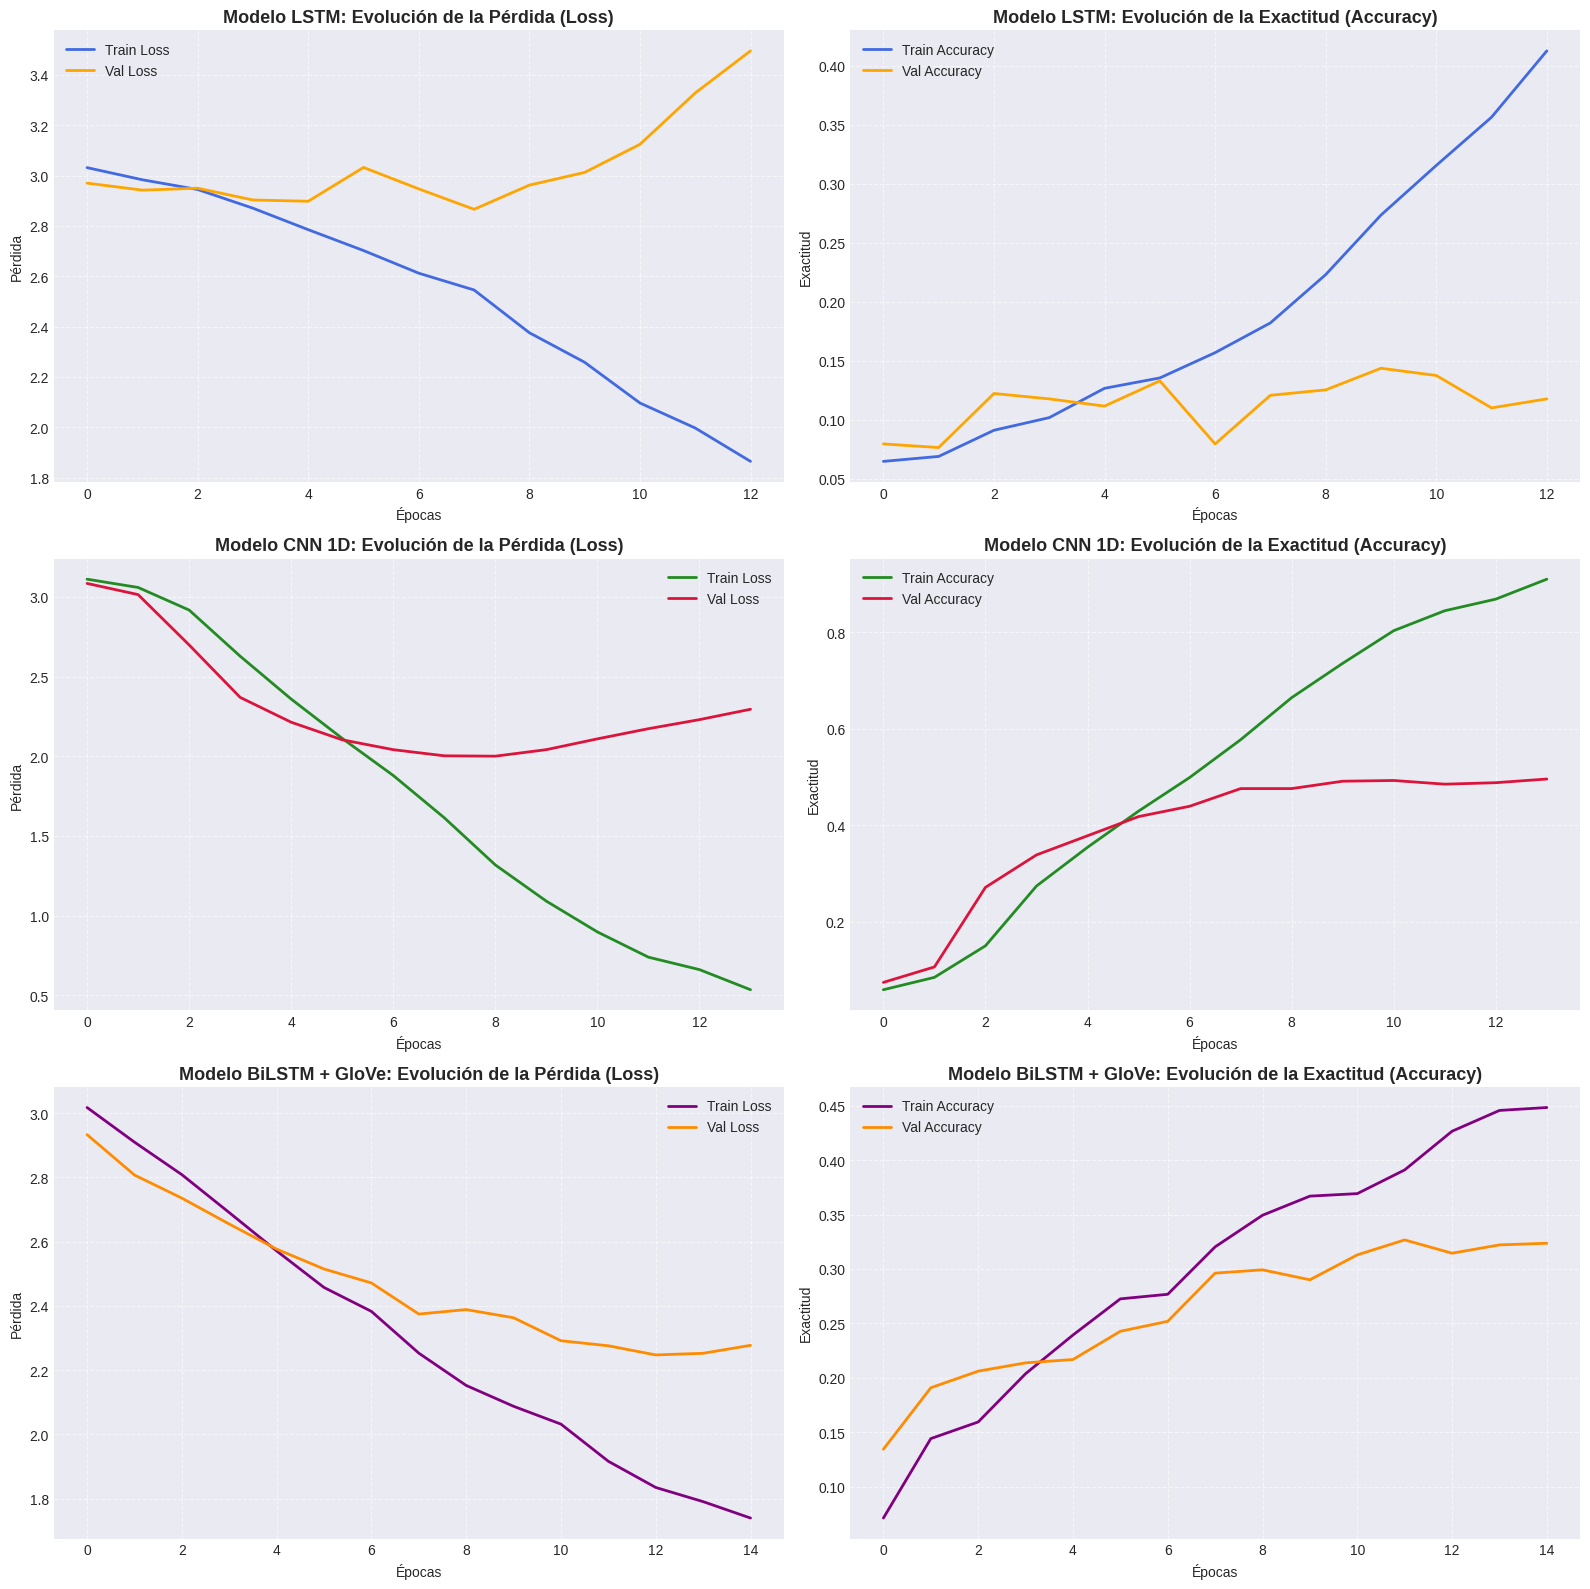

In [ ]:
import matplotlib.pyplot as plt

# Crear una figura con 3 filas y 2 columnas para mostrar Loss y Accuracy de los tres modelos
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# 1. CURVAS DEL MODELO RECURRENTE (LSTM)
# Graficar Pérdida (Loss) - LSTM
axes[0, 0].plot(lstm_history.history['loss'], label='Train Loss', color='royalblue', linewidth=2)
axes[0, 0].plot(lstm_history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
axes[0, 0].set_title('Modelo LSTM: Evolución de la Pérdida (Loss)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Épocas')
axes[0, 0].set_ylabel('Pérdida')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# Graficar Exactitud (Accuracy) - LSTM
axes[0, 1].plot(lstm_history.history['accuracy'], label='Train Accuracy', color='royalblue', linewidth=2)
axes[0, 1].plot(lstm_history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
axes[0, 1].set_title('Modelo LSTM: Evolución de la Exactitud (Accuracy)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Épocas')
axes[0, 1].set_ylabel('Exactitud')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# 2. CURVAS DEL MODELO CONVOLUCIONAL (CNN 1D)
# Graficar Pérdida (Loss) - CNN 1D
axes[1, 0].plot(cnn_history.history['loss'], label='Train Loss', color='forestgreen', linewidth=2)
axes[1, 0].plot(cnn_history.history['val_loss'], label='Val Loss', color='crimson', linewidth=2)
axes[1, 0].set_title('Modelo CNN 1D: Evolución de la Pérdida (Loss)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Épocas')
axes[1, 0].set_ylabel('Pérdida')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Graficar Exactitud (Accuracy) - CNN 1D
axes[1, 1].plot(cnn_history.history['accuracy'], label='Train Accuracy', color='forestgreen', linewidth=2)
axes[1, 1].plot(cnn_history.history['val_accuracy'], label='Val Accuracy', color='crimson', linewidth=2)
axes[1, 1].set_title('Modelo CNN 1D: Evolución de la Exactitud (Accuracy)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Épocas')
axes[1, 1].set_ylabel('Exactitud')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# 3. CURVAS DEL MODELO BiLSTM + GloVe
# Graficar Pérdida (Loss) - BiLSTM + GloVe
axes[2, 0].plot(bilstm_history.history['loss'], label='Train Loss', color='purple', linewidth=2)
axes[2, 0].plot(bilstm_history.history['val_loss'], label='Val Loss', color='darkorange', linewidth=2)
axes[2, 0].set_title('Modelo BiLSTM + GloVe: Evolución de la Pérdida (Loss)', fontsize=13, fontweight='bold')
axes[2, 0].set_xlabel('Épocas')
axes[2, 0].set_ylabel('Pérdida')
axes[2, 0].legend()
axes[2, 0].grid(True, linestyle='--', alpha=0.6)

# Graficar Exactitud (Accuracy) - BiLSTM + GloVe
axes[2, 1].plot(bilstm_history.history['accuracy'], label='Train Accuracy', color='purple', linewidth=2)
axes[2, 1].plot(bilstm_history.history['val_accuracy'], label='Val Accuracy', color='darkorange', linewidth=2)
axes[2, 1].set_title('Modelo BiLSTM + GloVe: Evolución de la Exactitud (Accuracy)', fontsize=13, fontweight='bold')
axes[2, 1].set_xlabel('Épocas')
axes[2, 1].set_ylabel('Exactitud')
axes[2, 1].legend()
axes[2, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

EVALUACIÓN DE MODELOS
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
REPORTE: Random Forest (TF-IDF)
Balanced Accuracy: 0.5341
               precision    recall  f1-score   support

Ariana Grande       0.72      0.64      0.67        44
          BTS       0.94      0.78      0.85        41
      Beyoncé       0.61      0.61      0.61        51
Billie Eilish       1.00      0.28      0.43        18
      Cardi B       0.78      0.58      0.67        12
 Charlie Puth       0.60      0.23      0.33        13
     Coldplay       0.36      0.68      0.47        47
        Drake       0.73      0.78      0.76        79
     Dua Lipa       0.56      0.23      0.32        22
   Ed Sheeran       0.70      0.55      0.62        38
       Eminem       0.80      0.84      0.82        57
Justin Bieber       0.57      0.52      0.55        52
   Katy Perry       0.44      0.31      0.36        36
       Khalid       0.67     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


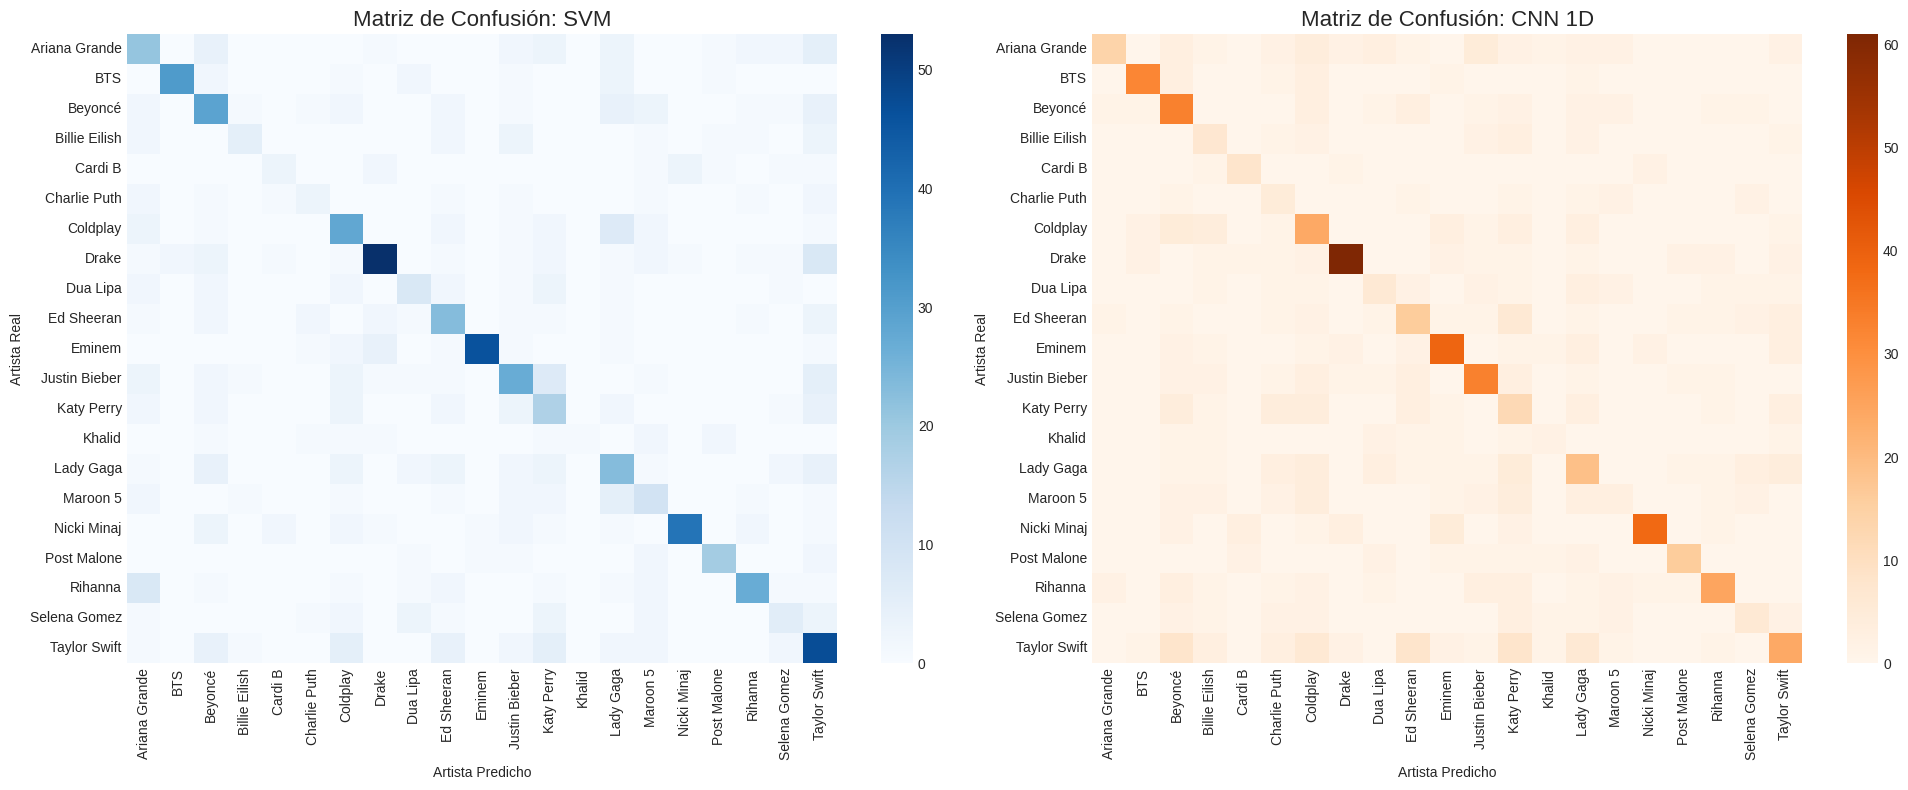

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("EVALUACIÓN DE MODELOS")

# 1. Obtener predicciones de los modelos clásicos svm y rf
y_pred_rf = rf_best.predict(X_test_tfidf)
y_pred_svm = svm_model.predict(X_test_tfidf)

# 2. Obtener predicciones de los modelos de Deep Learning
y_pred_lstm = np.argmax(lstm_model.predict(X_test_padded), axis=-1)
y_pred_cnn = np.argmax(cnn_model.predict(X_test_padded), axis=-1)

# Diccionario para iterar fácilmente
predicciones = {
    "Random Forest (TF-IDF)": y_pred_rf,
    "SVM (TF-IDF)": y_pred_svm,
    "LSTM Estándar (Embeddings)": y_pred_lstm,
    "CNN 1D (Embeddings)": y_pred_cnn
}

nombres_artistas = encoder.classes_

# Predicciones de los 2 modelos nuevos
y_pred_bilstm_glove = np.argmax(bilstm_glove_model.predict(X_test_seq_pad), axis=-1)

predicciones["BiLSTM + GloVe"] = y_pred_bilstm_glove


# 3. Imprimir el reporte de clasificación y Balanced Accuracy
for nombre, y_pred in predicciones.items():
    b_acc = balanced_accuracy_score(y_test, y_pred)

    print(f"REPORTE: {nombre}")
    print(f"Balanced Accuracy: {b_acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=nombres_artistas))

# 4. Graficar Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matriz SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=False, cmap='Blues', ax=axes[0], xticklabels=nombres_artistas, yticklabels=nombres_artistas)
axes[0].set_title('Matriz de Confusión: SVM', fontsize=16)
axes[0].set_ylabel('Artista Real')
axes[0].set_xlabel('Artista Predicho')

# Matriz CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=False, cmap='Oranges', ax=axes[1], xticklabels=nombres_artistas, yticklabels=nombres_artistas)
axes[1].set_title('Matriz de Confusión: CNN 1D', fontsize=16)
axes[1].set_ylabel('Artista Real')
axes[1].set_xlabel('Artista Predicho')

plt.tight_layout()
plt.show()

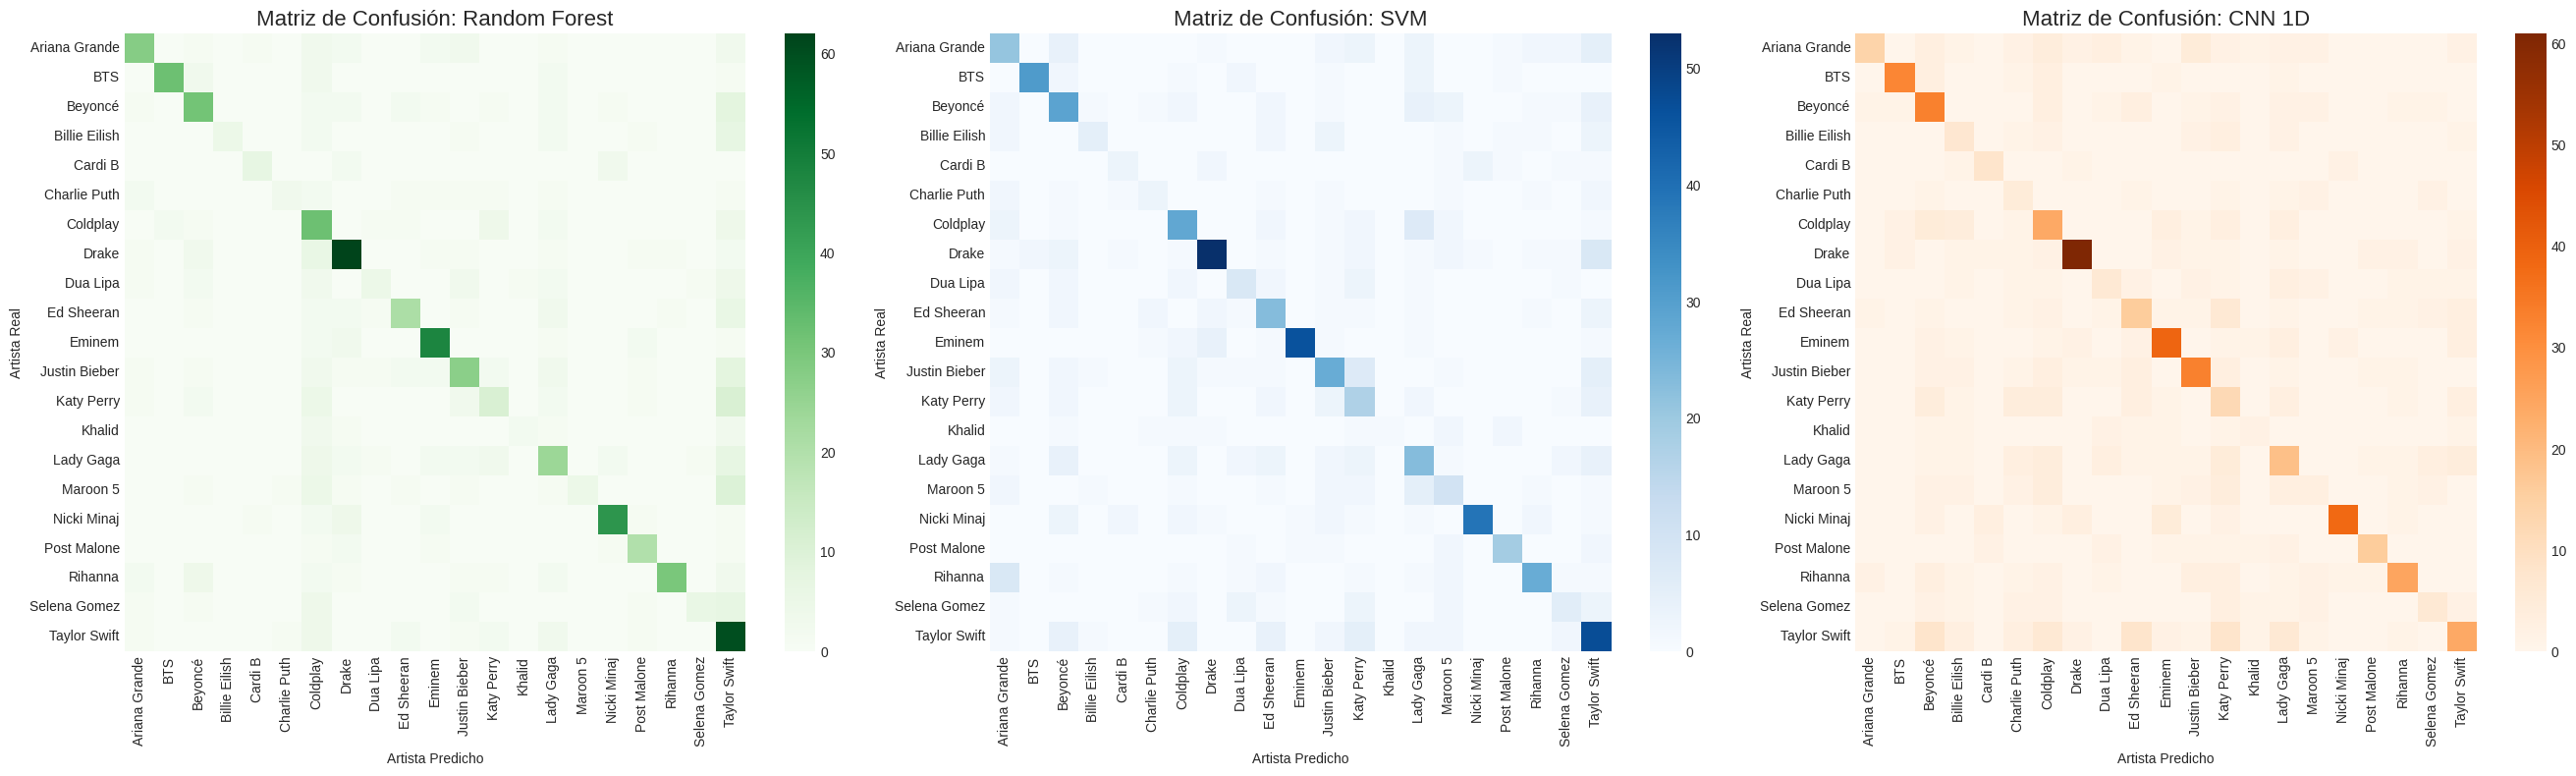

In [ ]:
# 4. Graficar Matrices de Confusión (los 3 modelos con mejor desempeño)
fig, axes = plt.subplots(1, 3, figsize=(27, 8))

# Matriz Random Forest (mejor modelo)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=False, cmap='Greens', ax=axes[0],
            xticklabels=nombres_artistas, yticklabels=nombres_artistas)
axes[0].set_title('Matriz de Confusión: Random Forest', fontsize=16)
axes[0].set_ylabel('Artista Real')
axes[0].set_xlabel('Artista Predicho')

# Matriz SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=False, cmap='Blues', ax=axes[1],
            xticklabels=nombres_artistas, yticklabels=nombres_artistas)
axes[1].set_title('Matriz de Confusión: SVM', fontsize=16)
axes[1].set_ylabel('Artista Real')
axes[1].set_xlabel('Artista Predicho')

# Matriz CNN 1D
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=False, cmap='Oranges', ax=axes[2],
            xticklabels=nombres_artistas, yticklabels=nombres_artistas)
axes[2].set_title('Matriz de Confusión: CNN 1D', fontsize=16)
axes[2].set_ylabel('Artista Real')
axes[2].set_xlabel('Artista Predicho')

plt.tight_layout()
plt.show()


##5.3 Comparación de resultados entre modelos

Tras evaluar sobre el conjunto de prueba independiente (818 canciones nunca vistas), los resultados consolidados —ordenados por la métrica principal F1-Macro— son:
| Modelo | Representación | Accuracy | Balanced Accuracy | F1-Macro |
|----------|----------|----------:|----------:|----------:|
| **Random Forest** | TF-IDF (n-gramas 1–2) | **0.615** | **0.534** | **0.563** |
| SVM (linear, C=1) | TF-IDF (n-gramas 1–2) | 0.570 | 0.499 | 0.512 |
| CNN 1D | Embeddings desde cero | 0.505 | 0.476 | 0.461 |
| BiLSTM + GloVe | Embeddings preentrenados | 0.384 | 0.345 | 0.341 |
| LSTM estándar | Embeddings desde cero | 0.131 | 0.122 | 0.083 |

Tres observaciones estructuran la lectura de la tabla:

1.	Los modelos clásicos superaron a todas las arquitecturas de Deep Learning. Random Forest lidera en las tres métricas, seguido por SVM. Como referencia, un clasificador aleatorio en 21 clases balanceadas rondaría el 4,8% de exactitud, y uno que predijera siempre la clase mayoritaria alcanzaría ~9,7%: todos los modelos excepto el LSTM estándar superan ampliamente ambas líneas base.

2.	Dentro del Deep Learning, la CNN fue la arquitectura más competitiva, quedando a ~5 puntos de F1 del SVM pese a su sobreajuste.

3.	Los embeddings preentrenados marcaron una diferencia sustancial entre las recurrentes: el BiLSTM con GloVe multiplica varias veces más el F1-Macro del LSTM desde cero (0.341 vs. 0.078). La transferencia de conocimiento semántico rescató a la arquitectura recurrente del colapso, aunque no bastó para alcanzar a la CNN ni a los métodos clásicos.

##5.4 Análisis crítico de los resultados

¿Por qué gana TF-IDF + Random Forest?

La identificación de autoría en letras musicales resulta ser, en esencia, un problema de firmas léxicas: cada artista utiliza un repertorio de palabras, jergas y nombres propios altamente característico (se verifica en la sección 5.6 con las importancias de características). La representación TF-IDF captura exactamente eso —presencia y peso de términos distintivos— sin necesitar el orden de las palabras. Los árboles del ensamble explotan estos términos como nodos de decisión de alta pureza, y la agregación del bosque los hace robustos al ruido. En otras palabras: la señal discriminativa de este problema es principalmente léxica, no secuencial, por lo que la ventaja teórica de las redes recurrentes (modelar el orden) no encuentra aquí materia prima que explotar.


¿Por qué la CNN es la mejor red?

Sus filtros convolucionales con max pooling operan de facto como detectores de n-gramas relevantes en cualquier posición del texto — una versión aprendida y densa de lo que TF-IDF con bigramas hace de forma estadística. La CNN converge hacia la misma solución conceptual que los modelos clásicos (detectar frases-firma), lo que explica que su rendimiento se les acerque, y su sobreajuste refleja que además intenta memorizar más de lo que los datos permiten generalizar.

¿Por qué fracasan las recurrentes y qué revela el contraste LSTM vs. BiLSTM+GloVe?

Con ~125 canciones de entrenamiento promedio por clase, el LSTM desde cero debe aprender simultáneamente los embeddings (640.000 parámetros solo en esa capa) y la dinámica de sus compuertas: la tarea excede los datos y la red degenera en predicciones concentradas en pocas clases. El BiLSTM+GloVe aísla la causa: al recibir los embeddings ya aprendidos (y congelados), la misma familia arquitectónica pasa de un F1 de 0.078 a 0.341. Esto demuestra que el cuello de botella no era la arquitectura recurrente en sí, sino la imposibilidad de aprender representaciones semánticas desde cero con tan pocos datos. Aun así, GloVe está entrenado sobre Wikipedia y texto periodístico, un registro alejado de la jerga lírica, lo cual limita el techo de la transferencia.

Lectura conjunta: los resultados no permiten concluir que "el Deep Learning es peor para texto", sino algo más preciso y útil: bajo restricción severa de datos y cuando la señal es léxica, la complejidad secuencial no se amortiza. Es una conclusión consistente con la práctica de la industria, donde los baselines TF-IDF siguen siendo competitivos en corpus pequeños.


##5.5 Análisis de errores y limitaciones de los modelos

Patrones por clase (matrices de confusión y reportes)

La inspección de los reportes por clase y las matrices de confusión revela tres patrones nítidos:

1.	Firmas léxicas fuertes → clasificación sobresaliente. En Random Forest, BTS (F1 = 0.85, precisión 0.94) y Eminem (F1 = 0.82; en SVM alcanza 0.88) son las clases mejor resueltas, junto con Nicki Minaj (F1 = 0.83). BTS se distingue por las romanizaciones de coreano —tokens que ningún otro artista comparte—, y los artistas de rap por su jerga explícita y densidad léxica. Son clases con vocabulario casi privado, ideal para TF-IDF.

2.	Alta precisión / bajo recall → modelos conservadores con clases minoritarias. Billie Eilish obtiene en RF precisión perfecta (1.00) pero recall de solo 0.28; Maroon 5 replica el patrón (1.00 / 0.19). Cuando el modelo se atreve a predecir estas clases, acierta siempre, pero la mayoría de sus canciones son absorbidas por clases pop mayores: el vocabulario melancólico-romántico que las caracteriza no les es exclusivo.

3.	El fenómeno se agrava en las redes: en el LSTM colapsado, BTS actúa como sumidero extremo (recall 0.90, precisión 0.12) — la red minimiza la pérdida derivando la mayoría de las predicciones hacia unas pocas clases, dejando a varias (Beyoncé, Coldplay, Eminem, Ed Sheeran) sin una sola predicción correcta —, y en el BiLSTM el sumidero persiste de forma atenuada en Coldplay (recall 0.64, precisión 0.31).

Limitaciones de los modelos

•	Volumen de datos vs. arquitecturas secuenciales: ~2.600 canciones de entrenamiento repartidas en 21 clases es una base insuficiente para redes recurrentes entrenadas desde cero, como demostró el colapso del LSTM y el sobreajuste de la CNN.

•	Techo de la información unimodal: la exactitud máxima alcanzada (~61%) sugiere un límite intrínseco del texto puro. La identidad artística reside también en el ritmo, la melodía, la producción y la voz — dimensiones ausentes en este corpus. Sobre el papel, una balada de Selena Gomez y una de Dua Lipa pueden compartir prácticamente el mismo vocabulario.

•	Sesgo hacia la firma superficial: los modelos aprenden en parte marcadores triviales (nombres propios, ad-libs, menciones del propio artista) más que "estilo" en sentido profundo. Esto infla el rendimiento en clases con marcadores explícitos y lo deprime en artistas líricamente genéricos.

•	Ruido residual del dominio: pese a la limpieza profunda, subsisten romanizaciones, onomatopeyas y jerga fuera del alcance de los lematizadores y de los diccionarios de VADER y GloVe, construidos sobre inglés estándar


In [ ]:
from sklearn.metrics import f1_score, accuracy_score

resumen = []
for nombre, y_pred in predicciones.items():
    resumen.append({
        'Modelo': nombre,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Balanced Accuracy': round(balanced_accuracy_score(y_test, y_pred), 3),
        'F1-Macro': round(f1_score(y_test, y_pred, average='macro'), 3)
    })

df_resumen = pd.DataFrame(resumen).sort_values('F1-Macro', ascending=False)
display(df_resumen)

,Modelo,Accuracy,Balanced Accuracy,F1-Macro
0,Random Forest (TF-IDF),0.615,0.534,0.563
1,SVM (TF-IDF),0.570,0.499,0.512
3,CNN 1D (Embeddings),0.517,0.475,0.472
4,BiLSTM + GloVe,0.394,0.348,0.345
2,LSTM Estándar (Embeddings),0.116,0.115,0.068


##5.6 Análisis visual, semántico e interpretabilidad de los modelos

Para comprender en profundidad el comportamiento de los clasificadores y las razones subyacentes de sus confusiones, se implementó una capa de análisis descriptivo enfocada en la polaridad emocional, la estructura léxica de las letras y los términos que el mejor modelo utiliza para decidir. Estas visualizaciones actúan como puente analítico entre las métricas de rendimiento (sección 5.3) y la naturaleza cualitativa del dominio musical, y responden directamente la segunda pregunta de investigación (P2).

##5.6.1 Perfil afectivo: Swarm Plots y dispersión de valencia (VADER)

Se emplearon gráficos de enjambre (swarm plots) para mapear la distribución de las canciones de cada uno de los 21 artistas según su sentimiento dominante (positivo, negativo o neutral) y la intensidad de dicho sentimiento, complementados con un gráfico de dispersión que ubica a cada artista según su valencia positiva y negativa promedio.

Justificación de uso: a diferencia de un histograma o un boxplot, el swarm plot muestra cada canción como un punto individual, permitiendo observar simultáneamente el volumen de canciones por artista, la proporción entre polaridades y la concentración exacta de intensidades, sin solapamiento de datos. El scatter de valencias promedio, por su parte, sintetiza los 21 perfiles en un solo plano comparable: los artistas sobre la diagonal poseen un repertorio predominantemente negativo, y bajo ella, predominantemente positivo.

Aporte a la interpretación: las visualizaciones revelan huellas emocionales claramente diferenciadas. Cardi B es el único artista cuyo promedio se ubica sobre la diagonal (valencia negativa 0.19 vs. positiva 0.11), seguida de cerca por Eminem y Nicki Minaj, coherente con la crudeza temática del rap. En el extremo opuesto, BTS presenta la valencia negativa más baja del corpus (~0.04) con predominio positivo, y el grueso de los artistas pop (Ariana Grande, Justin Bieber, Beyoncé, Taylor Swift) se agrupa en la zona positiva del plano. Esta diferenciación afectiva ayuda a explicar los resultados de clasificación: los artistas con perfil emocional extremo y distintivo (Cardi B, Eminem, BTS) obtienen F1 altos, mientras que el denso conglomerado pop de la zona positiva-moderada coincide exactamente con las clases que los modelos confunden entre sí.

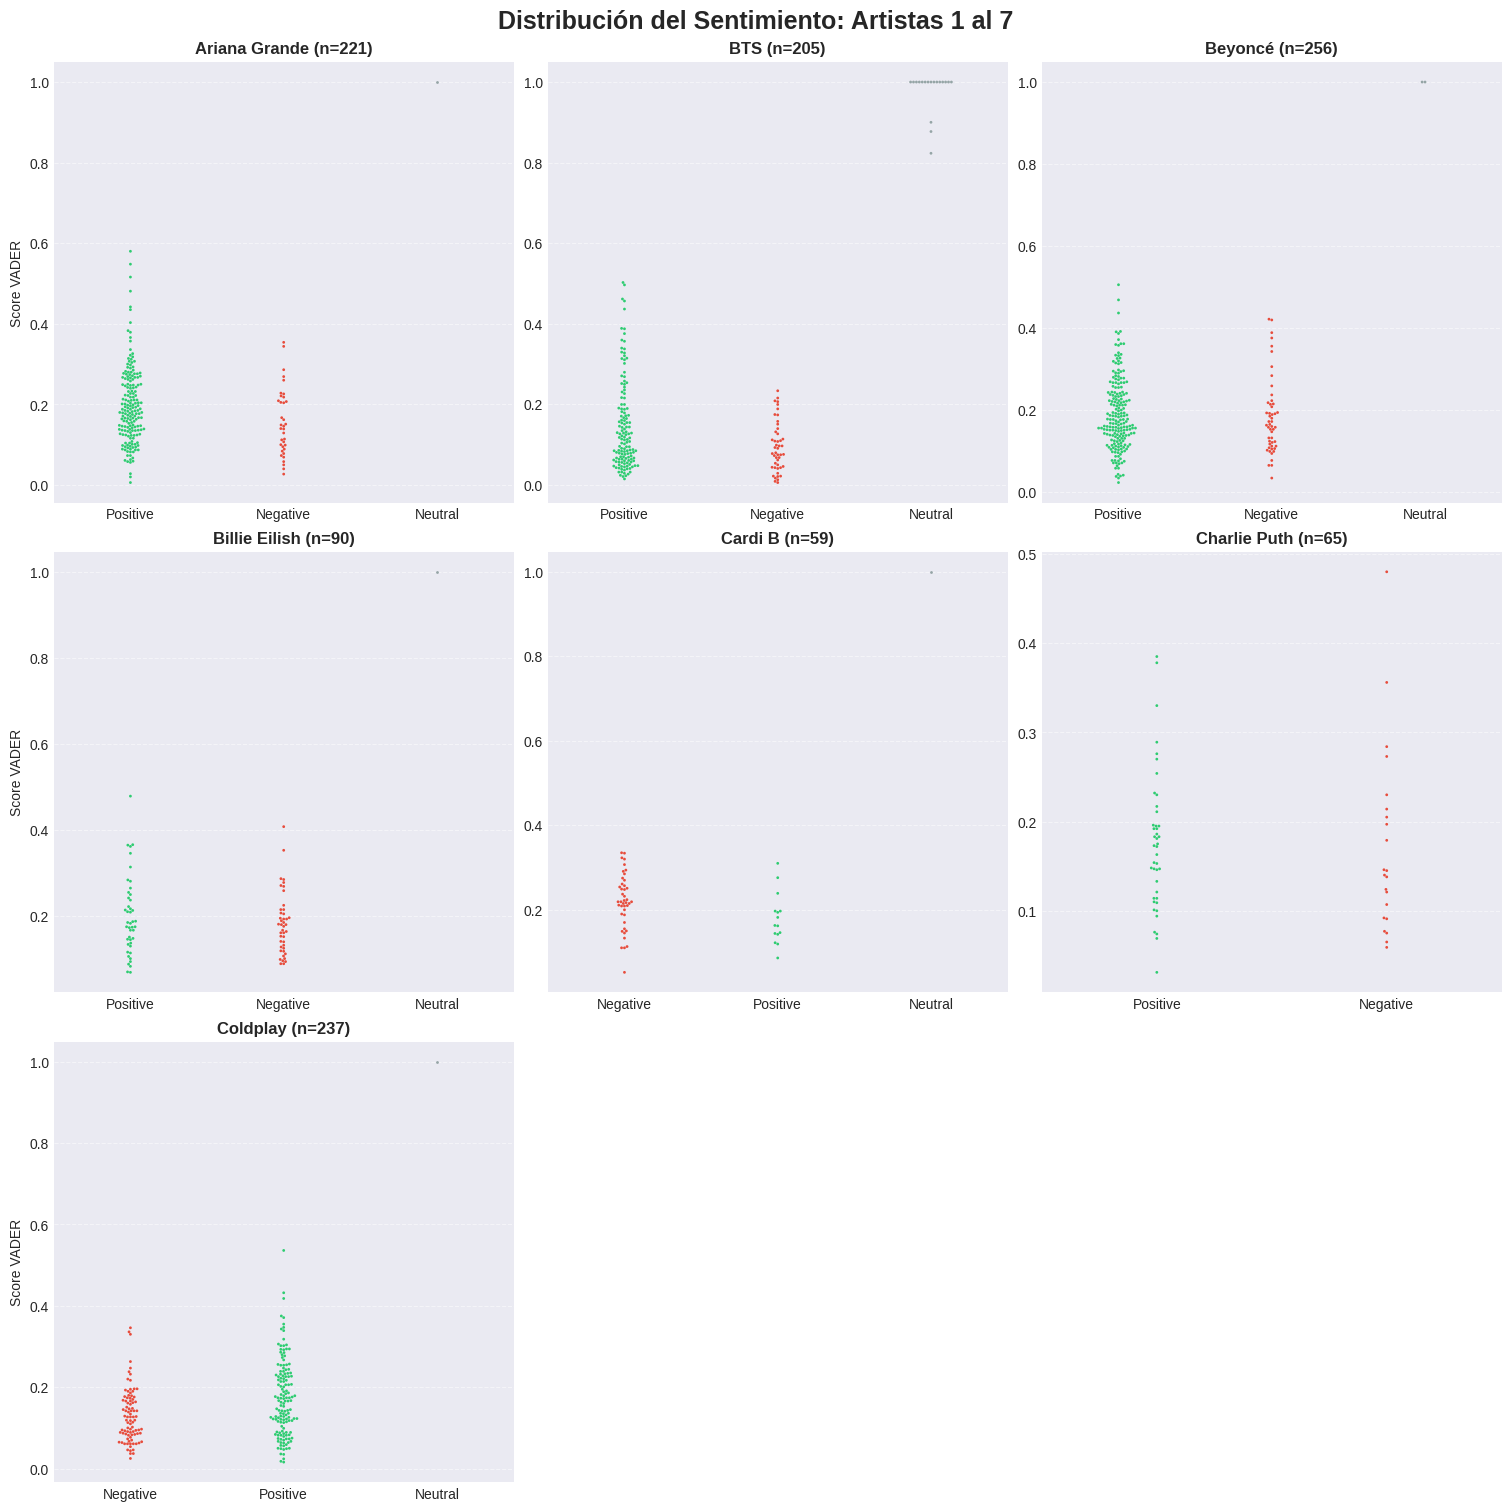

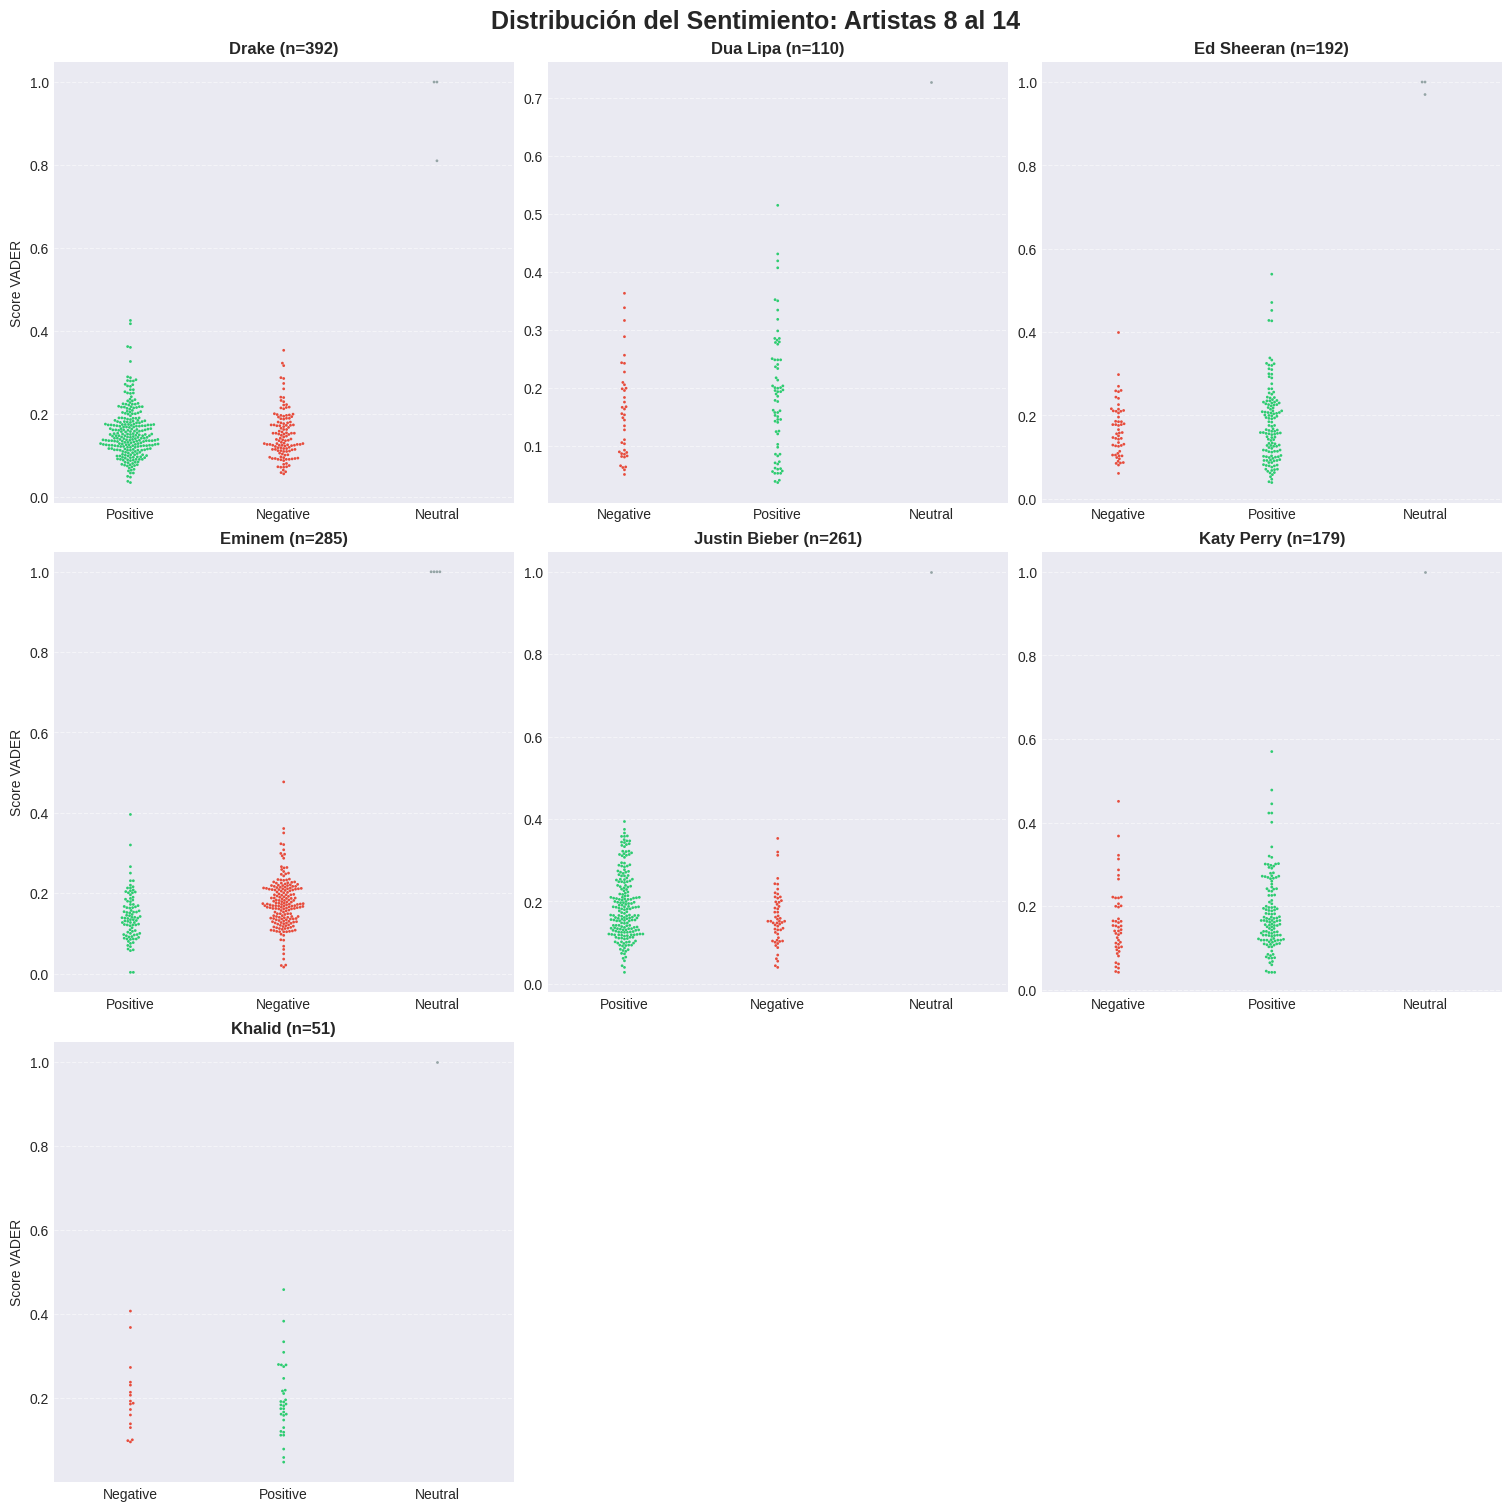

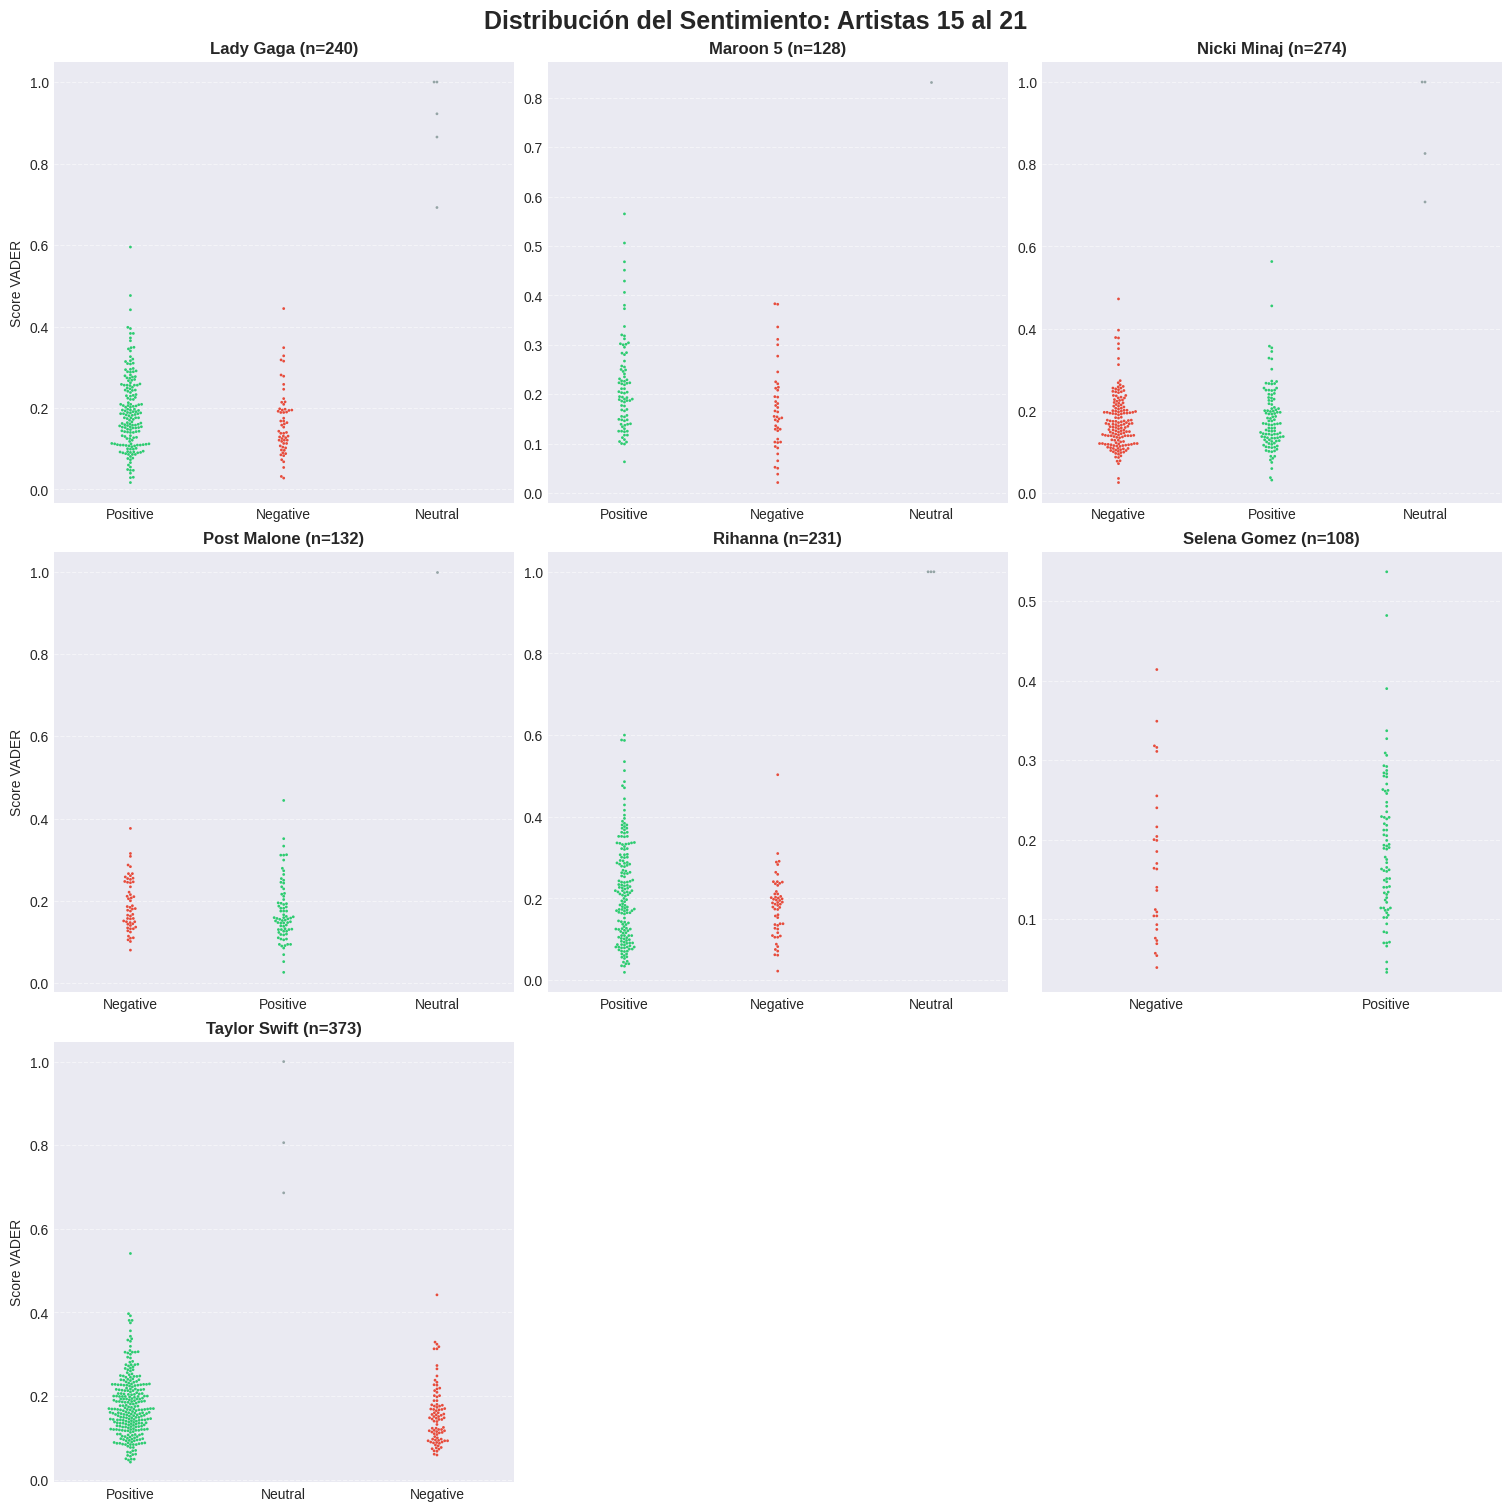

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sentimiento_artistas(df, inicio, fin, cols=3):
    """Grafica swarm plots de sentimiento para los artistas en el rango [inicio:fin]."""
    artistas = df['Artist'].unique()[inicio:fin]
    rows = math.ceil(len(artistas) / cols)
    fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows), constrained_layout=True)
    axs_flat = axs.flatten()
    paleta = {'Negative': '#e74c3c', 'Positive': '#2ecc71', 'Neutral': '#95a5a6'}

    for i, artist in enumerate(artistas):
        df_temp = df[df['Artist'] == artist]
        sns.swarmplot(data=df_temp, x="dominant_sentiment", y="dominant_sentiment_score",
                      ax=axs_flat[i], palette=paleta, hue="dominant_sentiment", size=2, legend=False)
        axs_flat[i].set_title(f"{artist} (n={len(df_temp)})", fontsize=12, fontweight='bold')
        axs_flat[i].set_xlabel('')
        axs_flat[i].set_ylabel('Score VADER' if i % cols == 0 else '')
        axs_flat[i].grid(axis='y', linestyle='--', alpha=0.5)

    for j in range(len(artistas), len(axs_flat)):
        axs_flat[j].axis('off')

    fig.suptitle(f"Distribución del Sentimiento: Artistas {inicio + 1} al {min(fin, len(df['Artist'].unique()))}",
                 fontsize=18, fontweight='bold')
    plt.show()

# Los 21 artistas en tres tandas de 7 para que se vea mas o menos bien
plot_sentimiento_artistas(df_clean, 0, 7)
plot_sentimiento_artistas(df_clean, 7, 14)
plot_sentimiento_artistas(df_clean, 14, 21)

##5.6.2 Riqueza léxica por artista

Se calculó el porcentaje de palabras únicas sobre el total de palabras emitidas por cada artista (type-token ratio), representado en un gráfico de barras ordenado.

Justificación de uso: la riqueza léxica cuantifica la diversidad del vocabulario de un autor. Dado que los modelos clásicos operan sobre frecuencias de términos (TF-IDF), un vocabulario más amplio y variado genera más dimensiones distintivas y, por tanto, mayor capacidad de discriminación esperada.

Aporte a la interpretación: los artistas de rap y hip-hop Cardi B (19%), Khalid, Eminem junto con Billie Eilish lideran la riqueza léxica, mientras que Rihanna (~6,5%), Justin Bieber y Taylor Swift ocupan los últimos lugares, con vocabularios más repetitivos propios del pop comercial y sus estribillos. Cabe una precisión metodológica: esta métrica es sensible al volumen total de palabras (artistas con menos canciones, como Cardi B o Khalid, tienden a ratios más altos), por lo que se interpreta como indicador aproximado y no como medida absoluta. Aun así, el patrón es consistente con los resultados: los artistas de vocabulario denso y jerga particular se clasifican bien, y los de léxico genérico y repetitivo alimentan el "efecto sumidero" descrito en 5.5.

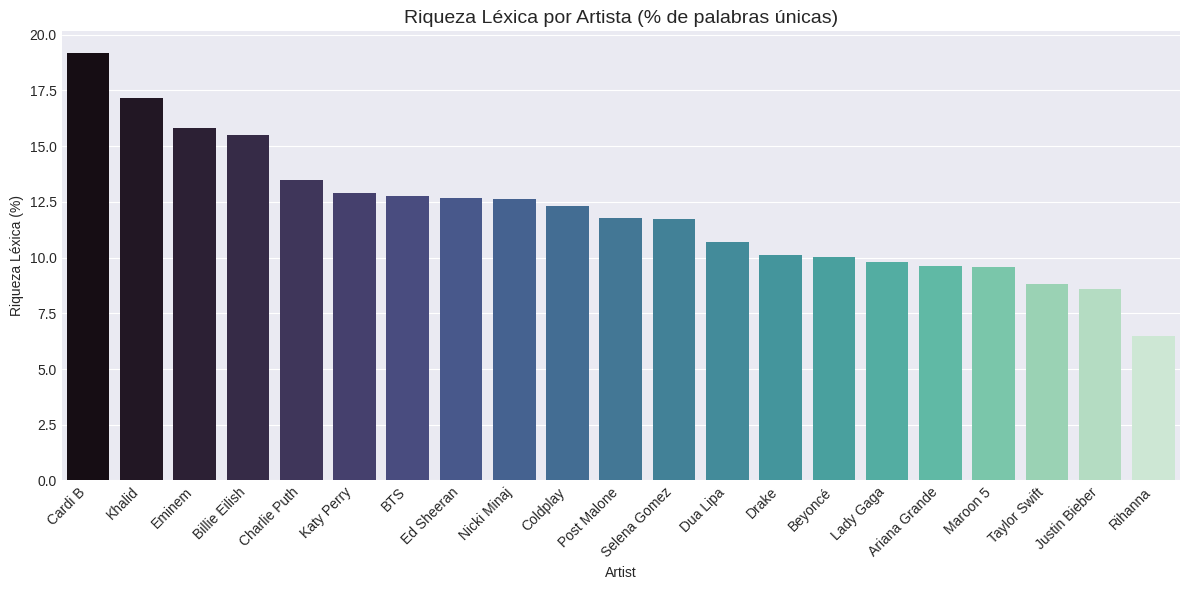

In [ ]:
lexical_stats = []
for artist, group in df_clean.groupby('Artist'):
    all_words = ' '.join(group['Lyric_Clean']).split()
    total = len(all_words)
    unique = len(set(all_words))
    lexical_stats.append({
        'Artist': artist,
        'total_words': total,
        'unique_words': unique,
        'lexical_richness': round((unique / total) * 100, 2) if total > 0 else 0
    })

df_lexical = pd.DataFrame(lexical_stats).sort_values('lexical_richness', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_lexical, x='Artist', y='lexical_richness', hue='Artist', palette='mako', legend=False)
plt.title('Riqueza Léxica por Artista (% de palabras únicas)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Riqueza Léxica (%)')
plt.tight_layout()
plt.show()

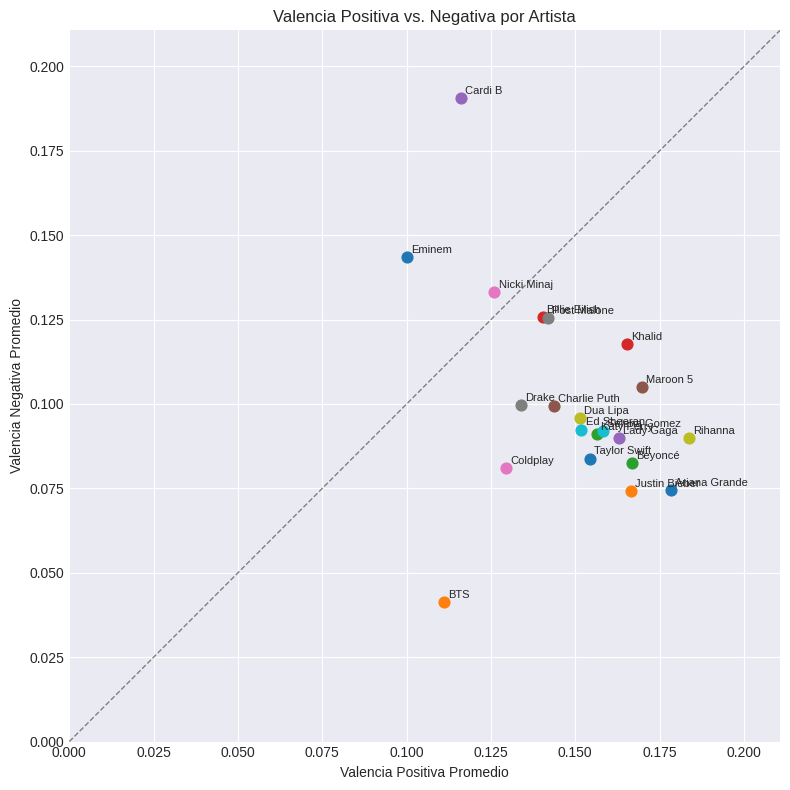

In [ ]:
means_df = df_clean.groupby('Artist')[['positive', 'negative']].mean().reset_index()

plt.figure(figsize=(8, 8))
for _, row in means_df.iterrows():
    plt.scatter(row['positive'], row['negative'], s=60)
    plt.annotate(row['Artist'], (row['positive'], row['negative']), fontsize=8, xytext=(3, 3), textcoords='offset points')

lims = [0, max(means_df['positive'].max(), means_df['negative'].max()) + 0.02]
plt.plot(lims, lims, linestyle='--', color='gray', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Valencia Positiva Promedio')
plt.ylabel('Valencia Negativa Promedio')
plt.title('Valencia Positiva vs. Negativa por Artista')
plt.tight_layout()
plt.show()

##5.6.3 Nubes de palabras (Word Clouds)

Se generaron las nubes con las 80 palabras más frecuentes de los seis artistas con mayor volumen de canciones (Eminem, Taylor Swift, Drake, Beyoncé, Nicki Minaj y Justin Bieber).

Justificación de uso: permiten una inspección cualitativa inmediata de los tokens de mayor frecuencia que los modelos asimilaron, haciendo visible en segundos lo que las matrices TF-IDF codifican numéricamente.

Aporte a la interpretación: las nubes visualizan de forma explícita el "efecto sumidero" identificado en las matrices de confusión. Mientras Eminem, Drake y Nicki Minaj dominan sus nubes con jerga explícita y marcadores propios (incluidos sus propios nombres artísticos, que funcionan como firma), Taylor Swift, Justin Bieber y Beyoncé comparten un lexicón abrumadoramente homogéneo de términos genéricos ("love", "know", "want", "baby", "got"). Esta redundancia semántica confirma por qué los clasificadores, desprovistos del audio y la melodía, concentran sus confusiones dentro del género pop y por qué las clases pop de mayor volumen absorben las predicciones ambiguas.

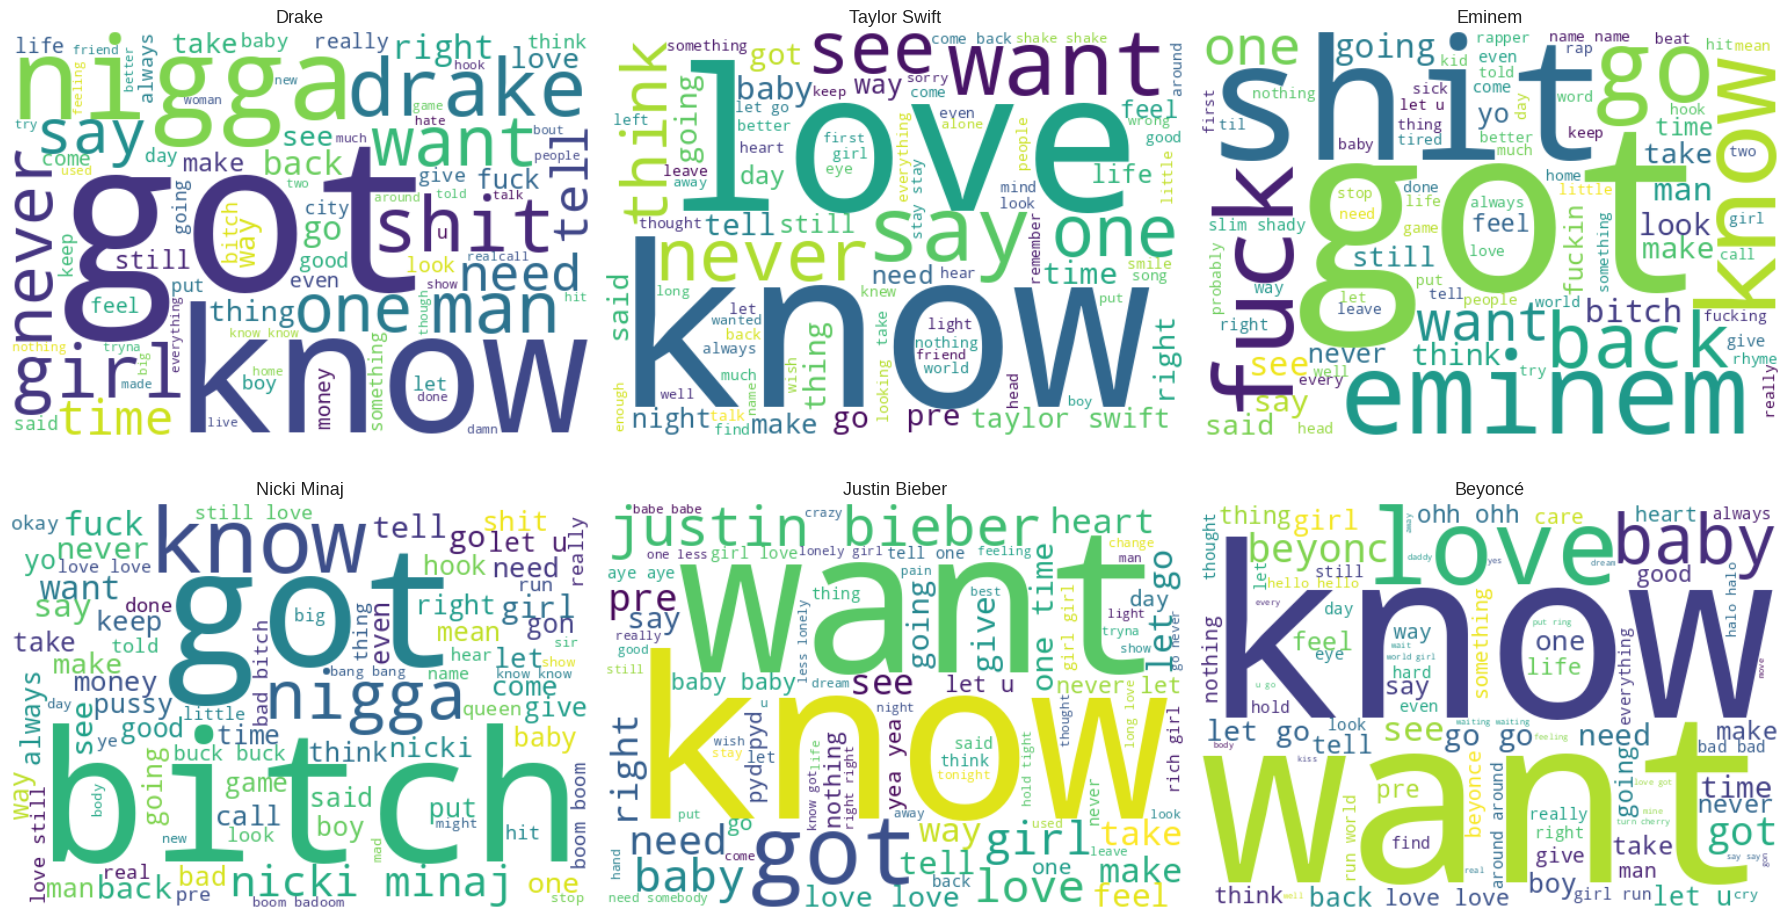

In [ ]:
from wordcloud import WordCloud

def plot_wordclouds(df, artists, cols=3):
    rows = int(np.ceil(len(artists) / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    axs = axs.flatten()
    for i, artist in enumerate(artists):
        text = ' '.join(df[df['Artist'] == artist]['Lyric_Clean'])
        wc = WordCloud(background_color='white', max_words=80, width=500, height=350).generate(text)
        axs[i].imshow(wc, interpolation='bilinear')
        axs[i].set_title(artist, fontsize=13)
        axs[i].axis('off')
    for j in range(len(artists), len(axs)):
        axs[j].axis('off')
    plt.tight_layout()
    plt.show()

top_artists = df_clean['Artist'].value_counts().head(6).index.tolist()
plot_wordclouds(df_clean, top_artists)

##5.6.4 Interpretabilidad del mejor modelo: importancia de características en Random Forest

Como cierre del análisis, se mapeó el atributo feature_importances_ del Random Forest contra el vocabulario del TfidfVectorizer, identificando los 25 términos con mayor poder discriminativo global (medido como reducción media de impureza de Gini).

Aporte a la interpretación: el ranking confirma empíricamente todas las hipótesis interpretativas anteriores y revela con precisión cómo decide el mejor modelo:

•	Los nombres propios de los artistas encabezan el ranking: "drake" (0.0126), "eminem", "rihanna", "nicki", "cardi", "beyonc", "justin", "shady". La auto-referencia —común en el rap y el pop— funciona como una firma casi infalible: si la palabra "drake" aparece en una letra, la canción es de Drake con altísima probabilidad. Estos términos generan nodos de decisión de pureza casi perfecta.

•	Los nombres de los integrantes de BTS ("jhope", "jimin", "jin", "jungkook", "rm", "suga") aparecen como características independientes de alto peso, explicando el F1 de 0.85 de esa clase: su vocabulario es literalmente exclusivo.

•	La jerga explícita ("bitch", "nigga", "shit", "fuck") actúa como segundo nivel de decisión, segmentando el bloque rap/hip-hop del resto del corpus.

•	Marcadores estructurales como "pre" (residuo de etiquetas "Pre-Chorus" del scraping) también aparecen con peso, lo que constituye un hallazgo honesto sobre ruido residual: parte de la señal aprendida es un artefacto del formato de los datos y no del estilo lírico.

•	En contraste, los términos genéricos compartidos ("like", "baby", "girl", "not") aparecen con importancias bajas y difusas: son frecuentes pero no discriminan, explicando algorítmicamente la confusión dentro del pop.
Síntesis crítica: el éxito del Random Forest descansa menos en capturar un "estilo" literario profundo y más en explotar marcadores superficiales hiper-específicos (nombres propios, ad-libs, jerga de género musical). Esto es a la vez su fortaleza (eficacia, interpretabilidad) y su límite: ante un artista nuevo sin marcadores explícitos, o ante letras que no se auto-referencian, el techo de discriminación caería hacia el vocabulario compartido del género. Este hallazgo conecta directamente con la limitación de "sesgo hacia la firma superficial" descrita en 5.5 y con la propuesta de enfoques multimodales de la sección 6.


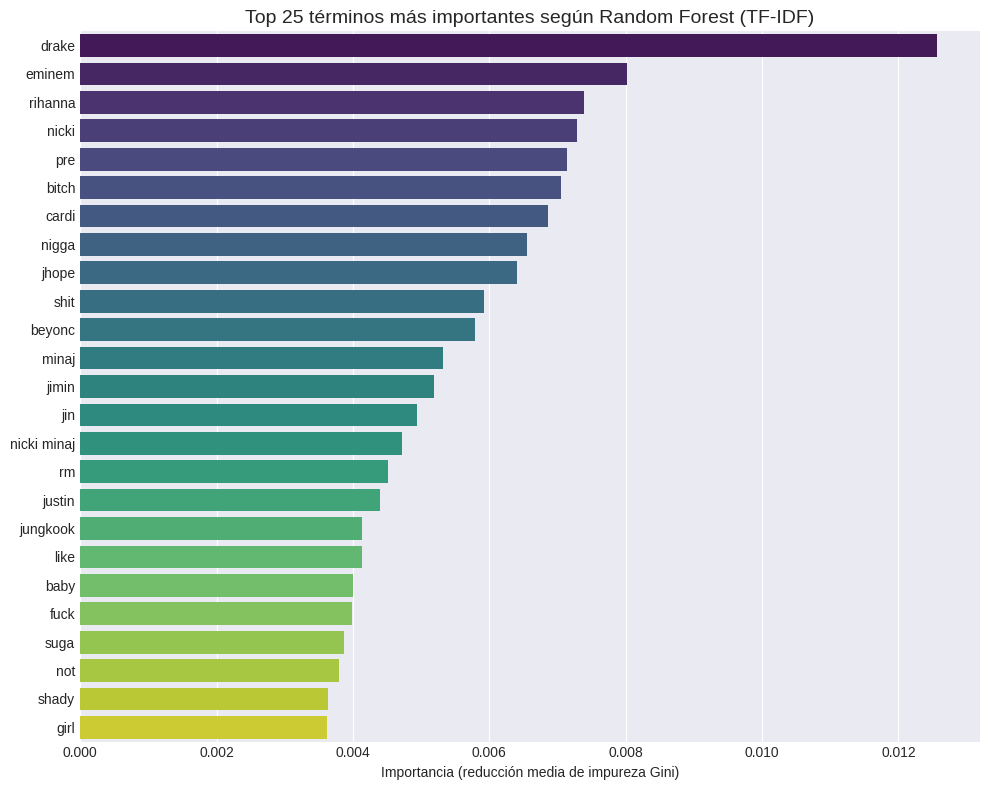

,termino,importancia
1050,drake,0.012567
1136,eminem,0.008013
3645,rihanna,0.007382
2946,nicki,0.007289
3420,pre,0.007145
366,bitch,0.007050
629,cardi,0.006858
2948,nigga,0.006546
2056,jhope,0.006402
3873,shit,0.005926


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Unir cada palabra del vocabulario TF-IDF con su importancia según Random Forest
importancias = pd.DataFrame({
    'termino': tfidf.get_feature_names_out(),
    'importancia': rf_best.feature_importances_
}).sort_values('importancia', ascending=False)

# Top 25 términos más discriminativos
top_n = importancias.head(25)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_n, y='termino', x='importancia', hue='termino',
            palette='viridis', legend=False)
plt.title('Top 25 términos más importantes según Random Forest (TF-IDF)', fontsize=14)
plt.xlabel('Importancia (reducción media de impureza Gini)')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(importancias.head(25))

# 6.01 Clasificación de polaridad emocional (objetivo de la propuesta)

La propuesta original planteaba como objetivo la clasificación automática de la
polaridad emocional de las letras. Dado que el corpus no incluye anotaciones de
sentimiento realizadas por humanos, las etiquetas se generan mediante VADER
(supervisión débil o *weak labeling*), práctica habitual cuando no existe corpus
anotado para el dominio. Esto impone un matiz interpretativo que se declara desde
el inicio: los modelos aprenden a **aproximar el criterio del léxico VADER**, no un
"sentimiento verdadero" validado externamente. Bajo esa premisa, la comparación
entre familias de modelos sigue siendo válida: la pregunta pasa a ser qué
representación y arquitectura aprende mejor dicha función de polaridad.

Dos decisiones de diseño, fundamentadas en el EDA afectivo (sección 5.6.1):

**(a)** se excluye la clase Neutral, cuyo soporte en el corpus es prácticamente
nulo según los swarm plots, quedando un problema binario Positivo/Negativo.

**(b)** al ser binario, se incorporan las curvas ROC-AUC comprometidas en la
propuesta, que en este formato sí son legibles y comparables entre modelos.
Se reutilizan los mismos pipelines de texto (Lyric_Clean para clásicos,
Lyric_Sequence para redes), el mismo esquema de partición estratificada 80/20 +
80/20 y las mejores configuraciones de hiperparámetros halladas en la sección 4,
garantizando comparabilidad con la tarea de autoría.

In [ ]:
from sklearn.model_selection import train_test_split

# Distribución de las etiquetas VADER (verifica el soporte de Neutral)
print(df_clean['dominant_sentiment'].value_counts())

# Etiqueta binaria: Neutral se excluye por soporte casi nulo
df_sent = df_clean[df_clean['dominant_sentiment'].isin(['Positive', 'Negative'])].copy()
y_s = (df_sent['dominant_sentiment'] == 'Positive').astype(int)
print(f"\nBalance binario:\n{y_s.value_counts()}")

# Split estratificado (mismo esquema que la tarea de autoría)
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    df_sent['Lyric_Clean'], y_s, test_size=0.2, random_state=42, stratify=y_s)
Xs_train, Xs_val, ys_train, ys_val = train_test_split(
    Xs_train, ys_train, test_size=0.2, random_state=42, stratify=ys_train)

print(f"\nTrain: {len(Xs_train)} | Val: {len(Xs_val)} | Test: {len(Xs_test)}")

dominant_sentiment
Positive    2680
Negative    1354
Neutral       55
Name: count, dtype: int64

Balance binario:
dominant_sentiment
1    2680
0    1354
Name: count, dtype: int64

Train: 2581 | Val: 646 | Test: 807


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# TF-IDF nuevo, ajustado SOLO con el train de esta tarea (sin fuga)
tfidf_s = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
Xs_train_tfidf = tfidf_s.fit_transform(Xs_train)
Xs_val_tfidf   = tfidf_s.transform(Xs_val)
Xs_test_tfidf  = tfidf_s.transform(Xs_test)

# Se transfieren las mejores configuraciones halladas en la sección 4
rf_sent = RandomForestClassifier(n_estimators=300, min_samples_split=10,
                                 max_depth=None, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
rf_sent.fit(Xs_train_tfidf, ys_train)
print("Random Forest (sentimiento) entrenado.")

# probability=True habilita predict_proba para las curvas ROC
svm_sent = SVC(kernel='linear', C=1, class_weight='balanced',
               probability=True, random_state=42)
svm_sent.fit(Xs_train_tfidf, ys_train)
print("SVM (sentimiento) entrenado.")

Random Forest (sentimiento) entrenado.
SVM (sentimiento) entrenado.


Se reutilizan los hiperparámetros ganadores de la sección 4 en vez de repetir la búsqueda

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv1D, GlobalMaxPooling1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf

# Texto secuencial de las MISMAS filas del split
Xs_train_dl = df_sent.loc[Xs_train.index, 'Lyric_Sequence']
Xs_val_dl   = df_sent.loc[Xs_val.index,   'Lyric_Sequence']
Xs_test_dl  = df_sent.loc[Xs_test.index,  'Lyric_Sequence']

tok_s = Tokenizer(num_words=10000, oov_token="<OOV>")
tok_s.fit_on_texts(Xs_train_dl)
Xtr_pad = pad_sequences(tok_s.texts_to_sequences(Xs_train_dl), maxlen=300, padding='post', truncating='post')
Xva_pad = pad_sequences(tok_s.texts_to_sequences(Xs_val_dl),   maxlen=300, padding='post', truncating='post')
Xte_pad = pad_sequences(tok_s.texts_to_sequences(Xs_test_dl),  maxlen=300, padding='post', truncating='post')

pesos = compute_class_weight('balanced', classes=np.unique(ys_train), y=ys_train)
pesos_dict_s = dict(zip(np.unique(ys_train), pesos))

# LSTM binaria: salida sigmoide + binary_crossentropy
lstm_sent = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=300),
    LSTM(64),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_sent.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_sent.fit(Xtr_pad, ys_train, epochs=15, batch_size=32,
              validation_data=(Xva_pad, ys_val), class_weight=pesos_dict_s,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])

# CNN 1D binaria
cnn_sent = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=300),
    Conv1D(128, 5, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
cnn_sent.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn_sent.fit(Xtr_pad, ys_train, epochs=15, batch_size=32,
             validation_data=(Xva_pad, ys_val), class_weight=pesos_dict_s,
             callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.5389 - loss: 0.6934 - val_accuracy: 0.6285 - val_loss: 0.6869
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5916 - loss: 0.6753 - val_accuracy: 0.5139 - val_loss: 0.6698
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6656 - loss: 0.5577 - val_accuracy: 0.6424 - val_loss: 0.6558
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7195 - loss: 0.4539 - val_accuracy: 0.6455 - val_loss: 0.7637
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7377 - loss: 0.4015 - val_accuracy: 0.6223 - val_loss: 0.8924
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7590 - loss: 0.3303 - val_accuracy: 0.5991 - val_loss: 1.2147
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7660 - loss: 0.3346 - val_accuracy: 0.5557 - val_loss: 1.2372
Epoch 8/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7563 - loss: 0.3225 - val_accuracy: 0.6533 - val_loss: 1.

Evaluación con ROC-AUC

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


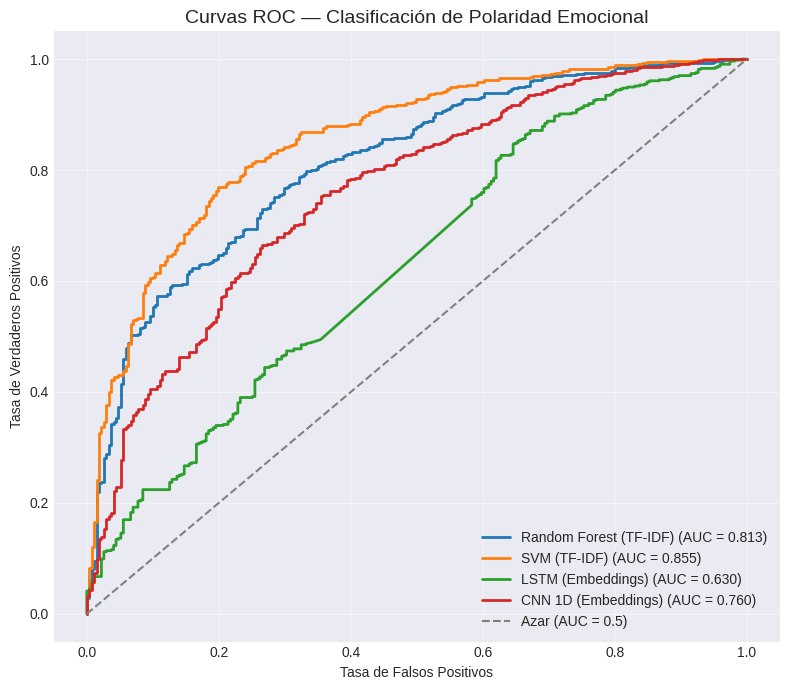

,Modelo,Accuracy,F1 (clase Positiva),F1-Macro,ROC-AUC
1,SVM (TF-IDF),0.796,0.851,0.763,0.855
0,Random Forest (TF-IDF),0.753,0.828,0.695,0.813
3,CNN 1D (Embeddings),0.720,0.793,0.680,0.760
2,LSTM (Embeddings),0.678,0.776,0.601,0.630



REPORTE — SVM (TF-IDF)
              precision    recall  f1-score   support

    Negative       0.72      0.63      0.67       271
    Positive       0.82      0.88      0.85       536

    accuracy                           0.80       807
   macro avg       0.77      0.75      0.76       807
weighted avg       0.79      0.80      0.79       807



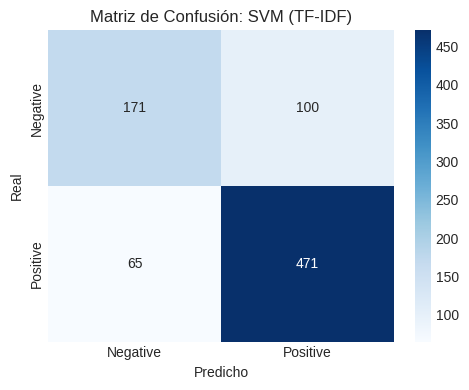

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                             roc_auc_score, f1_score, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Probabilidad de la clase positiva para cada modelo
probas_s = {
    'Random Forest (TF-IDF)': rf_sent.predict_proba(Xs_test_tfidf)[:, 1],
    'SVM (TF-IDF)':           svm_sent.predict_proba(Xs_test_tfidf)[:, 1],
    'LSTM (Embeddings)':      lstm_sent.predict(Xte_pad).ravel(),
    'CNN 1D (Embeddings)':    cnn_sent.predict(Xte_pad).ravel(),
}

resumen_s = []
plt.figure(figsize=(8, 7))
for nombre, p in probas_s.items():
    pred = (p >= 0.5).astype(int)
    auc = roc_auc_score(ys_test, p)
    fpr, tpr, _ = roc_curve(ys_test, p)
    plt.plot(fpr, tpr, linewidth=2, label=f'{nombre} (AUC = {auc:.3f})')
    resumen_s.append({'Modelo': nombre,
                      'Accuracy': round(accuracy_score(ys_test, pred), 3),
                      'F1 (clase Positiva)': round(f1_score(ys_test, pred), 3),
                      'F1-Macro': round(f1_score(ys_test, pred, average='macro'), 3),
                      'ROC-AUC': round(auc, 3)})

plt.plot([0, 1], [0, 1], '--', color='gray', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos'); plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC — Clasificación de Polaridad Emocional', fontsize=14)
plt.legend(loc='lower right'); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()

df_resumen_s = pd.DataFrame(resumen_s).sort_values('ROC-AUC', ascending=False)
display(df_resumen_s)

# Reporte y matriz de confusión del mejor modelo
mejor = df_resumen_s.iloc[0]['Modelo']
pred_mejor = (probas_s[mejor] >= 0.5).astype(int)
print(f"\nREPORTE — {mejor}")
print(classification_report(ys_test, pred_mejor, target_names=['Negative', 'Positive']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(ys_test, pred_mejor), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title(f'Matriz de Confusión: {mejor}'); plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

<font color="#240046" face="Georgia" size="6">
6. Conclusiones
</h1>



##6.1 Síntesis de los hallazgos principales

El desarrollo de este proyecto permitió contrastar el rendimiento de cinco enfoques de clasificación multiclase sobre el Song Lyrics Dataset, junto con un análisis descriptivo del perfil léxico y afectivo de 21 artistas. Los hallazgos centrales son:

1.	Superioridad de los modelos clásicos: Random Forest sobre representaciones TF-IDF alcanzó el mejor rendimiento global (F1-Macro 0.563, Balanced Accuracy 0.534, Accuracy 0.615), seguido por SVM lineal (F1-Macro 0.512). Ambos superaron a todas las arquitecturas de Deep Learning, con una fracción de su costo computacional (34 y 117 segundos de entrenamiento con búsqueda de hiperparámetros incluida).

2.	La CNN 1D fue la red neuronal más competitiva (F1-Macro 0.458), gracias a que sus filtros convolucionales convergen hacia la misma estrategia que TF-IDF: detectar frases-firma locales independientes de la posición. Su principal debilidad fue el sobreajuste, visible en las curvas de aprendizaje.

3.	El contraste entre recurrentes fue el hallazgo más revelador: el LSTM entrenado desde cero colapsó (F1-Macro 0.062), concentrando sus predicciones en pocas clases sumidero, mientras que la misma familia arquitectónica con embeddings preentrenados (BiLSTM + GloVe) mejoro mucho el rendimiento (F1-Macro 0.349) y mostró curvas de convergencia estables. Esto aísla la causa del fracaso: no fue la recurrencia en sí, sino la imposibilidad de aprender representaciones semánticas desde cero con ~125 canciones por clase.

4.	La señal discriminativa del problema es principalmente léxica, no secuencial: el análisis de importancias reveló que el mejor modelo decide a partir de marcadores hiper-específicos (nombres propios, integrantes de BTS, jerga explícita del rap) más que de estructura gramatical, lo que explica por qué modelar el orden de las palabras no aportó ventaja.

##6.2



##6.3 Limitaciones del trabajo

•	Volumen del corpus: tras la depuración de duplicados y versiones, ~2.600 muestras de entrenamiento para 21 clases es una densidad muy baja para entrenar arquitecturas profundas desde cero, restringiendo el potencial evaluable del Deep Learning.

•	Ambigüedad unimodal: analizar la música exclusivamente desde sus letras omite dimensiones críticas de la identidad artística — ritmo, melodía, producción, modulación vocal. Esto impone un techo algorítmico (~61% de exactitud), pues sobre el papel una balada melancólica y un éxito bailable pueden compartir el mismo vocabulario.

•	Sesgo hacia la firma superficial: parte del rendimiento descansa en marcadores triviales (auto-referencias, nombres de integrantes, ad-libs) e incluso en artefactos del scraping (el token "pre", residuo de etiquetas "Pre-Chorus", figura entre las características más importantes). El modelo identifica "quién se nombra", no plenamente "cómo escribe".

•	Herramientas ajenas al dominio: VADER, los lematizadores y GloVe fueron construidos sobre inglés estándar (redes sociales, Wikipedia, prensa), por lo que la jerga lírica, las onomatopeyas y las romanizaciones de coreano/japonés escapan parcialmente a sus diccionarios, introduciendo ruido en el análisis de sentimiento y limitando la cobertura de la transferencia.

•	Desbalance residual: pese a los pesos de clase, las clases minoritarias (Khalid, Charlie Puth) mantuvieron recalls bajos en todos los modelos, indicando que la ponderación mitiga pero no resuelve la escasez de ejemplos.

##6.4 Posibles mejoras y trabajo futuro

1.	Transformers preentrenados (fine-tuning): sustituir las recurrentes clásicas por modelos basados en atención (BERT, RoBERTa o DistilBERT). El hallazgo del BiLSTM+GloVe demuestra que la transferencia de conocimiento es la palanca correcta; los Transformers la llevan al extremo, pues llegan con representaciones contextuales completas y solo requieren ajuste fino, escenario ideal para corpus pequeños.

2.	Enfoque multimodal: combinar los vectores de texto con características acústicas (espectrogramas de Mel, MFCC) extraídas del audio, atacando directamente el techo unimodal identificado.

3.	Ampliación y depuración del corpus: incorporar discografías completas, equilibrar la representación por artista y refinar la limpieza (eliminar residuos como "pre", excluir o tratar por separado las letras romanizadas no inglesas) para reducir el ruido estructural.

4.	Modelamiento de tópicos (LDA / BERTopic): descubrir de forma no supervisada los temas subyacentes de las canciones (desamor, fiesta, crítica social) y usarlos como características adicionales, enriqueciendo la representación más allá de la frecuencia léxica.

5.	Evaluación de robustez de la firma: repetir el experimento excluyendo nombres propios y auto-referencias del vocabulario, para medir cuánto del rendimiento corresponde a "estilo" genuino versus marcadores superficiales — una extensión directa del análisis de interpretabilidad de la sección 5.6.4.


a
a
a

a
a
a
a
a

a
a
a

a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a

a
a

a
a
a
a
a

a
a
a
a


a
a
a

a
a
a
a
a

a
a
a

a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a

a
a

a
a
a
a
a

a
a
a
a


a
a
a

a
a
a
a
a

a
a
a

a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a

a
a

a
a
a
a
a

a
a
a
a


a
a
a

a
a
a
a
a

a
a
a

a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a

a
a

a
a
a
a
a

a
a
a
a


a
a
a

a
a
a
a
a

a
a
a

a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a

a
a

a
a
a
a
a

a
a
a
a


a
a
a

a
a
a
a
a

a
a
a

a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a

a
a

a
a
a
a
a

a
a
a
a


a
a
a

a
a
a
a
a

a
a
a

a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a

a
a

a
a
a
a
a

a
a
a
a


a
a
a

a
a
a
a
a

a
a
a

a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a

a
a

a
a
a
a
a

a
a
a
a


a
a
a

a
a
a
a
a

a
a
a

a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a

a
a

a
a
a
a
a

a
a
a
a


a
a
a

a
a
a
a
a

a
a
a

a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a

a
a

a
a
a
a
a

a
a
a
a


a
a
a

a
a
a
a
a

a
a
a

a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a
a
a
a
a
a

a
a
a
a
a
a
a

a
a
a
a
a

a
a

a
a
a
a
a

a
a
a
a
